In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm


C:\Users\x12la\AppData\Local\Temp\ipykernel_29200\1625810921.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


<h1> Load data 

In [33]:
# CMAQ lat/lon datafile
d03 = Dataset('C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc')
cmaq_lon,cmaq_lat = np.array(d03['lon']),np.array(d03['lat'])
cmaq_llat,cmaq_ulat,cmaq_llon,cmaq_ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()

In [3]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

#primary roads
primary_roads = gpd.read_file('C:/Users/x12la/Desktop/Scripts/tl_2016_us_primaryroads.shp')
primary_roads = primary_roads.to_crs('EPSG:4326')

In [17]:
# Upload Aconc shapefiles
base = gpd.read_file('COMBINE_ACONC_BASE_JanJulAvg_D03_censustracts.shp')
base = base.to_crs('EPSG:4326')

idling = gpd.read_file('COMBINE_ACONC_LOCUSIdling_HDVSpatial_JanJulAvg_D03_censustracts.shp')
idling = idling.to_crs('EPSG:4326')

renewal = gpd.read_file('COMBINE_ACONC_Renewal_JanJulAvg_D03_censustracts.shp')
renewal = renewal.to_crs('EPSG:4326')

zeropre2010s =  gpd.read_file('COMBINE_ACONC_ZeroPre2010s_Annual2023_avg_censustracts.shp')
zeropre2010s = zeropre2010s.to_crs('EPSG:4326')

In [117]:
## Upload Aconc shapefiles
base_o3 = gpd.read_file('MDA8O3_BASE_JanJulAvg_D03_censustracts.shp')
base_o3 = base_o3.to_crs('EPSG:4326')

idling_o3 = gpd.read_file('MDA8O3_LOCUSIdling_HDVSpatial_JanJulAvg_D03_censustracts.shp')
idling_o3 = idling_o3.to_crs('EPSG:4326')

renewal_o3 = gpd.read_file('MDA8O3_Renewal_JanJulAvg_D03_censustracts.shp')
renewal_o3 = renewal_o3.to_crs('EPSG:4326')

zeropre2010s_o3 =  gpd.read_file('MDA8O3_ZeroPre2010_AnnualAvg_censustracts.shp')
zeropre2010s_o3 = zeropre2010s_o3.to_crs('EPSG:4326')

In [200]:
#Clip geopandas files to CMAP
cmap_roads = gpd.clip(primary_roads, cmap_cty.to_crs('EPSG:4326'))
cmap_base = gpd.clip(base, cmap_cty.to_crs('EPSG:4326'))
cmap_idling = gpd.clip(idling, cmap_cty.to_crs('EPSG:4326'))
cmap_renewal = gpd.clip(renewal, cmap_cty.to_crs('EPSG:4326'))
cmap_zeropre2010s = gpd.clip(zeropre2010s, cmap_cty.to_crs('EPSG:4326'))

cmap_base_o3 = gpd.clip(base_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_idling_o3 = gpd.clip(idling_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_renewal_o3 = gpd.clip(renewal_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_zeropre2010s_o3 = gpd.clip(zeropre2010s_o3, cmap_cty.to_crs('EPSG:4326'))

In [107]:
# # # # Load in NHGIS of the 2019-2023 ACS
# demo_data = pd.read_csv('../demographic/nhgis0011_ds267_20235_tract.csv')

# census_tracts = gpd.read_file('../demographic/cmap_census_tracts2018.shp')
# census_tracts = census_tracts.to_crs('EPSG:4326')

# demo_joined = census_tracts.merge(demo_data, on='GISJOIN')
# domain_tracts = gpd.clip(census_tracts, cmap_cty.to_crs('EPSG:4326'))
# domain_demo   = gpd.clip(demo_joined,  cmap_cty.to_crs('EPSG:4326'))

In [108]:
benmap_df = pd.read_csv("BenMAP_Ready_USALEEP_AllCauseRates_OriginalYears.csv")
#benmap_df = pd.read_csv("../demographic/BenMAP_Ready_Tract_Incidence_CountyRatio_Edited.csv")

In [109]:
benmap_df.head()

,Endpoint Group,Endpoint,Race,Gender,Ethnicity,Start Age,End Age,TractFIPS,StateCountyFIPS,Type,Value
0,Mortality,"Mortality, All Cause",NaN,NaN,NaN,0,0,20100,1001,Incidence,0.020097
1,Mortality,"Mortality, All Cause",NaN,NaN,NaN,1,4,20100,1001,Incidence,0.002231
2,Mortality,"Mortality, All Cause",NaN,NaN,NaN,5,14,20100,1001,Incidence,0.000619
3,Mortality,"Mortality, All Cause",NaN,NaN,NaN,15,24,20100,1001,Incidence,0.000865
4,Mortality,"Mortality, All Cause",NaN,NaN,NaN,25,34,20100,1001,Incidence,0.002421


<h1> Data Formatting

In [201]:
benmap_df["StateCountyFIPS_v1"] = benmap_df["StateCountyFIPS"].astype(str).str.zfill(5)
benmap_df["TractFIPS_v1"] = benmap_df["TractFIPS"].astype(str).str.zfill(6)

# Use this if domain_demo/cmap_* GEOID values include "14000US"
benmap_df["GEOID"] =  benmap_df["StateCountyFIPS_v1"] + benmap_df["TractFIPS_v1"]

# Use this instead if your GEOID values are only 11-digit FIPS
# benmap_df["GEOID"] = benmap_df["StateCountyFIPS_v1"] + benmap_df["TractFIPS_v1"]

bmr_age_bins = {
    "0-0": "BMR_0_0",
    "1-4": "BMR_1_4",
    "5-14": "BMR_5_14",
    "15-24": "BMR_15_24",
    "25-34": "BMR_25_34",
    "35-44": "BMR_35_44",
    "45-54": "BMR_45_54",
    "55-64": "BMR_55_64",
    "65-74": "BMR_65_74",
    "75-84": "BMR_75_84",
    "85-99": "BMR_85_99",
}

benmap_df["AgeBin"] = (
    benmap_df["Start Age"].astype(str) + "-" + benmap_df["End Age"].astype(str)
)

benmap_df["BMR_Column"] = benmap_df["AgeBin"].map(bmr_age_bins)
benmap_df = benmap_df.dropna(subset=["BMR_Column"])

bmr_wide_df = (
    benmap_df
    .pivot_table(
        index="GEOID",
        columns="BMR_Column",
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

bmr_wide_df = bmr_wide_df[
    ["GEOID"] + sorted([col for col in bmr_wide_df.columns if col != "GEOID"])
]

In [202]:
pollutants = ["NO2", "PM25_EC", "PM25_TOT"]

base_pollutants = cmap_base[["GEOID"] + pollutants].copy()
base_pollutants = base_pollutants.rename(
    columns={col: f"base_{col}" for col in pollutants}
)

idling_pollutants = cmap_idling[["GEOID"] + pollutants].copy()
idling_pollutants = idling_pollutants.rename(
    columns={col: f"idling_{col}" for col in pollutants}
)

renewal_pollutants = cmap_renewal[["GEOID"] + pollutants].copy()
renewal_pollutants = renewal_pollutants.rename(
    columns={col: f"renewal_{col}" for col in pollutants}
)

zeropre2010s_pollutants = cmap_zeropre2010s[["GEOID"] + pollutants].copy()
zeropre2010s_pollutants = zeropre2010s_pollutants.rename(
    columns={col: f"zeropre2010s_{col}" for col in pollutants}
)

base_o3_col = cmap_base_o3[["GEOID", "O3"]].copy()
base_o3_col = base_o3_col.rename(columns={"O3": "base_O3"})

idling_o3_col = cmap_idling_o3[["GEOID", "O3"]].copy()
idling_o3_col = idling_o3_col.rename(columns={"O3": "idling_O3"})

renewal_o3_col = cmap_renewal_o3[["GEOID", "O3"]].copy()
renewal_o3_col = renewal_o3_col.rename(columns={"O3": "renewal_O3"})

zeropre2010s_o3_col = cmap_zeropre2010s_o3[["GEOID", "O3"]].copy()
zeropre2010s_o3_col = zeropre2010s_o3_col.rename(columns={"O3": "zeropre2010s_O3"})

aq_scenarios = (
    base_pollutants
    .merge(idling_pollutants, on="GEOID", how="inner")
    .merge(renewal_pollutants, on="GEOID", how="inner")
    .merge(zeropre2010s_pollutants, on="GEOID", how="inner")
    .merge(base_o3_col, on="GEOID", how="inner")
    .merge(idling_o3_col, on="GEOID", how="inner")
    .merge(renewal_o3_col, on="GEOID", how="inner")
    .merge(zeropre2010s_o3_col, on="GEOID", how="inner")
)


full_merged = (
    domain_demo
    .merge(aq_scenarios, on="GEOID", how="inner")
    .merge(bmr_wide_df, on="GEOID", how="inner")
)

full_merged

,GISJOIN,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,BMR_15_24,BMR_1_4,BMR_25_34,BMR_35_44,BMR_45_54,BMR_55_64,BMR_5_14,BMR_65_74,BMR_75_84,BMR_85_99
0,G1700910010900,17,091,010900,17091010900,109,Census Tract 109,G5020,S,189425605.0,...,0.000923,0.000226,0.001784,0.001916,0.007119,0.010016,0.000125,0.016647,0.042583,0.124401
1,G1800890043401,18,089,043401,18089043401,434.01,Census Tract 434.01,G5020,S,160485773.0,...,0.000397,0.000227,0.000988,0.001073,0.002360,0.009373,0.000123,0.019890,0.062501,0.191983
2,G1701970883902,17,197,883902,17197883902,8839.02,Census Tract 8839.02,G5020,S,116132140.0,...,0.001283,0.000211,0.000929,0.000853,0.002451,0.007468,0.000203,0.017051,0.054653,0.144738
3,G1701970883808,17,197,883808,17197883808,8838.08,Census Tract 8838.08,G5020,S,30930415.0,...,0.000491,0.000135,0.000789,0.000873,0.002193,0.006267,0.000135,0.016378,0.047602,0.145780
4,G1701970883811,17,197,883811,17197883811,8838.11,Census Tract 8838.11,G5020,S,23262854.0,...,0.001339,0.000162,0.001200,0.000531,0.003081,0.007070,0.000088,0.018483,0.085030,0.252770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1932,G1700970861012,17,097,861012,17097861012,8610.12,Census Tract 8610.12,G5020,S,14845555.0,...,0.000369,0.000134,0.000574,0.001724,0.002265,0.006222,0.000078,0.015847,0.048374,0.172071
1933,G1700970860809,17,097,860809,17097860809,8608.09,Census Tract 8608.09,G5020,S,8400459.0,...,0.000606,0.000129,0.000964,0.000870,0.002465,0.003091,0.000076,0.007860,0.039473,0.179613
1934,G1700970860811,17,097,860811,17097860811,8608.11,Census Tract 8608.11,G5020,S,17538320.0,...,0.000920,0.000143,0.001710,0.000240,0.002647,0.005310,0.000088,0.014616,0.049938,0.392590
1935,G1700970860806,17,097,860806,17097860806,8608.06,Census Tract 8608.06,G5020,S,5128895.0,...,0.000260,0.000141,0.001236,0.000699,0.002935,0.006124,0.000076,0.023256,0.049618,0.219332


<h1> Calculate Health outcomes 

In [203]:
# population data 
male_population_columns = {
    "Under 5 years": "ASNQE003",
    "5 to 9 years": "ASNQE004",
    "10 to 14 years": "ASNQE005",
    "15 to 17 years": "ASNQE006",
    "18 and 19 years": "ASNQE007",
    "20 years": "ASNQE008",
    "21 years": "ASNQE009",
    "22 to 24 years": "ASNQE010",
    "25 to 29 years": "ASNQE011",
    "30 to 34 years": "ASNQE012",
    "35 to 39 years": "ASNQE013",
    "40 to 44 years": "ASNQE014",
    "45 to 49 years": "ASNQE015",
    "50 to 54 years": "ASNQE016",
    "55 to 59 years": "ASNQE017",
    "60 and 61 years": "ASNQE018",
    "62 to 64 years": "ASNQE019",
    "65 and 66 years": "ASNQE020",
    "67 to 69 years": "ASNQE021",
    "70 to 74 years": "ASNQE022",
    "75 to 79 years": "ASNQE023",
    "80 to 84 years": "ASNQE024",
    "85 years and over": "ASNQE025"
}

female_population_columns = {
    "Under 5 years": "ASNQE027",
    "5 to 9 years": "ASNQE028",
    "10 to 14 years": "ASNQE029",
    "15 to 17 years": "ASNQE030",
    "18 and 19 years": "ASNQE031",
    "20 years": "ASNQE032",
    "21 years": "ASNQE033",
    "22 to 24 years": "ASNQE034",
    "25 to 29 years": "ASNQE035",
    "30 to 34 years": "ASNQE036",
    "35 to 39 years": "ASNQE037",
    "40 to 44 years": "ASNQE038",
    "45 to 49 years": "ASNQE039",
    "50 to 54 years": "ASNQE040",
    "55 to 59 years": "ASNQE041",
    "60 and 61 years": "ASNQE042",
    "62 to 64 years": "ASNQE043",
    "65 and 66 years": "ASNQE044",
    "67 to 69 years": "ASNQE045",
    "70 to 74 years": "ASNQE046",
    "75 to 79 years": "ASNQE047",
    "80 to 84 years": "ASNQE048",
    "85 years and over": "ASNQE049"
}

In [204]:
# 1. Calculate baseline mortality over age 30
# ============================================================

age_mapping = {
    "0-0": ["Under 5 years"],
    "1-4": ["Under 5 years"],
    "5-14": ["5 to 9 years", "10 to 14 years"],
    "15-24": ["15 to 17 years", "18 and 19 years", "20 years", "21 years", "22 to 24 years"],
    "25-34": ["25 to 29 years", "30 to 34 years"],
    "35-44": ["35 to 39 years", "40 to 44 years"],
    "45-54": ["45 to 49 years", "50 to 54 years"],
    "55-64": ["55 to 59 years", "60 and 61 years", "62 to 64 years"],
    "65-74": ["65 and 66 years", "67 to 69 years", "70 to 74 years"],
    "75-84": ["75 to 79 years", "80 to 84 years"],
    "85-99": ["85 years and over"]
}

for bmr_age_group, pop_age_groups in age_mapping.items():
    age_label = bmr_age_group.replace("-", "_")
    bmr_col = f"BMR_{age_label}"

    full_merged[f"BM_M_{age_label}"] = 0
    full_merged[f"BM_F_{age_label}"] = 0

    for pop_age_group in pop_age_groups:
        # Pop CT  * BMR CT 
        male_col = male_population_columns.get(pop_age_group)
        female_col = female_population_columns.get(pop_age_group)

        if male_col:
            full_merged[f"BM_M_{age_label}"] += full_merged[bmr_col] * full_merged[male_col]

        if female_col:
            full_merged[f"BM_F_{age_label}"] += full_merged[bmr_col] * full_merged[female_col]


# Only sum BMR groups where the age bin starts at 30+
over30_age_labels = ["35_44", "45_54", "55_64", "65_74", "75_84", "85_99"]

bm_male_cols = [f"BM_M_{age}" for age in over30_age_labels]
bm_female_cols = [f"BM_F_{age}" for age in over30_age_labels]

full_merged["BM_Male_Over30"] = full_merged[bm_male_cols].sum(axis=1)
full_merged["BM_Female_Over30"] = full_merged[bm_female_cols].sum(axis=1)
full_merged["BM_Total_Over30"] = (
    full_merged["BM_Male_Over30"] + full_merged["BM_Female_Over30"]
)


In [205]:
# Calculate attributable mortality by scenario
# ============================================================
# RR (Relative Risk) represents the increase in risk associated
# with a pollutant concentration increment reported in epidemiological studies.
# The concentration-response coefficient beta (β) is calculated as:
# beta = ln(RR) / concentration_increment
# where:
# - ln() is the natural logarithm
# - concentration_increment is the pollutant increment used in the study
# The attributable fraction (AF) is then calculated as:
# AF = 1 - exp(-beta * concentration)
# which estimates the fraction of health burden attributable
# to pollutant exposure within each census tract.

# For NO2  RR 1.04 (CI:1.01-1.06) per 10 micrograms per cubic meter
# Converted to ppb (10 micrograms per cubic meters ~ 5.3124 ppb)8)
# For NO2 — RR 1.04 (CI: 1.01-1.06) per 10 µg/m³ ≈ 5.3124 ppb → beta ≈ ln(1.04)/5.3124 = 0.00778 per ppb

# For PM2.5 Total — RR 1.03 (CI: 1.01-1.04) per 5 µg/m³ → beta ≈ ln(1.03)/5 = 0.00591 per µg/m³

# For PM2.5 EC — RR 1.02 (CI: 1.00-1.04) per 1 µg/m³ → beta ≈ ln(1.02)/1 = 0.0198 per µg/m³

# For MDA8 O3 — RR 1.05 (CI: 1.025-1.075) per 10 micrograms per cubic meter
# Converted to ppb (10 micrograms per cubic meter ~ 5.102 ppb)
# WHO 

# TUurner et al 2016 RR 1.02 (1.01-1.04) per 10 ppb o3 

pollutant_betas = {
    "NO2": {
        "col": "NO2",
        "beta": 0.00738,
        "lower": 0.00187,
        "upper": 0.01096,
    },
    "PM25_TOT": {
        "col": "PM25_TOT",
        "beta": 0.00591,
        "lower": 0.00199,
        "upper": 0.00784,
    },
    "PM25_EC": {
        "col": "PM25_EC",
        "beta": 0.0198,
        "lower": 0.0,
        "upper": 0.0392,
    },
    # WHO O3 RR
    "O3_WHO": {
        "col": "O3",
        "beta": 0.00956,
        "lower": 0.00488,
        "upper": 0.01420,
    },

    # Turner et al. 2016
    "O3_Turner2016": {
        "col": "O3",
        "beta": 0.00198,
        "lower": 0.000995,
        "upper": 0.00392,
    },
}

scenarios = ["base", "idling", "renewal", "zeropre2010s"]

for pollutant, info in pollutant_betas.items():
    pollutant_col = info["col"]

    for scenario in scenarios:
        conc_col = f"{scenario}_{pollutant_col}"

        af_col = f"AF_{pollutant}_{scenario}"
        af_lower_col = f"AF_{pollutant}_{scenario}_lower"
        af_upper_col = f"AF_{pollutant}_{scenario}_upper"

        crf_col = f"CRF_{pollutant}_{scenario}"
        crf_lower_col = f"CRF_{pollutant}_{scenario}_lower"
        crf_upper_col = f"CRF_{pollutant}_{scenario}_upper"

        full_merged[af_col] = 1 - np.exp(-info["beta"] * full_merged[conc_col])
        full_merged[af_lower_col] = 1 - np.exp(-info["lower"] * full_merged[conc_col])
        full_merged[af_upper_col] = 1 - np.exp(-info["upper"] * full_merged[conc_col])

        full_merged[crf_col] = full_merged["BM_Total_Over30"] * full_merged[af_col]
        full_merged[crf_lower_col] = full_merged["BM_Total_Over30"] * full_merged[af_lower_col]
        full_merged[crf_upper_col] = full_merged["BM_Total_Over30"] * full_merged[af_upper_col]

C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

In [206]:
for pollutant in pollutant_betas.keys():

    # Idling minus baseline
    full_merged[f"CRF_{pollutant}_idling_minus_base"] = (
        full_merged[f"CRF_{pollutant}_idling"]
        - full_merged[f"CRF_{pollutant}_base"]
    )

    full_merged[f"CRF_{pollutant}_idling_minus_base_lower"] = (
        full_merged[f"CRF_{pollutant}_idling_lower"]
        - full_merged[f"CRF_{pollutant}_base_lower"]
    )

    full_merged[f"CRF_{pollutant}_idling_minus_base_upper"] = (
        full_merged[f"CRF_{pollutant}_idling_upper"]
        - full_merged[f"CRF_{pollutant}_base_upper"]
    )

    # Renewal minus idling
    full_merged[f"CRF_{pollutant}_renewal_minus_idling"] = (
        full_merged[f"CRF_{pollutant}_renewal"]
        - full_merged[f"CRF_{pollutant}_idling"]
    )

    full_merged[f"CRF_{pollutant}_renewal_minus_idling_lower"] = (
        full_merged[f"CRF_{pollutant}_renewal_lower"]
        - full_merged[f"CRF_{pollutant}_idling_lower"]
    )

    full_merged[f"CRF_{pollutant}_renewal_minus_idling_upper"] = (
        full_merged[f"CRF_{pollutant}_renewal_upper"]
        - full_merged[f"CRF_{pollutant}_idling_upper"]
    )

    # Zero pre-2010 trucks minus idling
    full_merged[f"CRF_{pollutant}_zeropre2010s_minus_idling"] = (
        full_merged[f"CRF_{pollutant}_zeropre2010s"]
        - full_merged[f"CRF_{pollutant}_idling"]
    )

    full_merged[f"CRF_{pollutant}_zeropre2010s_minus_idling_lower"] = (
        full_merged[f"CRF_{pollutant}_zeropre2010s_lower"]
        - full_merged[f"CRF_{pollutant}_idling_lower"]
    )

    full_merged[f"CRF_{pollutant}_zeropre2010s_minus_idling_upper"] = (
        full_merged[f"CRF_{pollutant}_zeropre2010s_upper"]
        - full_merged[f"CRF_{pollutant}_idling_upper"]
    )

    # Zero pre-2010 trucks minus renewal
    full_merged[f"CRF_{pollutant}_zeropre2010s_minus_renewal"] = (
        full_merged[f"CRF_{pollutant}_zeropre2010s"]
        - full_merged[f"CRF_{pollutant}_renewal"]
    )

    full_merged[f"CRF_{pollutant}_zeropre2010s_minus_renewal_lower"] = (
        full_merged[f"CRF_{pollutant}_zeropre2010s_lower"]
        - full_merged[f"CRF_{pollutant}_renewal_lower"]
    )

    full_merged[f"CRF_{pollutant}_zeropre2010s_minus_renewal_upper"] = (
        full_merged[f"CRF_{pollutant}_zeropre2010s_upper"]
        - full_merged[f"CRF_{pollutant}_renewal_upper"]
    )

C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

In [207]:
summary_rows = []

for pollutant in pollutant_betas.keys():

    for scenario in scenarios:
        summary_rows.append({
            "Pollutant": pollutant,
            "Metric": scenario,
            "Total": full_merged[f"CRF_{pollutant}_{scenario}"].sum(),
            "Lower": full_merged[f"CRF_{pollutant}_{scenario}_lower"].sum(),
            "Upper": full_merged[f"CRF_{pollutant}_{scenario}_upper"].sum(),
        })

    summary_rows.append({
        "Pollutant": pollutant,
        "Metric": "idling_minus_base",
        "Total": full_merged[f"CRF_{pollutant}_idling_minus_base"].sum(),
        "Lower": full_merged[f"CRF_{pollutant}_idling_minus_base_lower"].sum(),
        "Upper": full_merged[f"CRF_{pollutant}_idling_minus_base_upper"].sum(),
    })

    summary_rows.append({
        "Pollutant": pollutant,
        "Metric": "renewal_minus_idling",
        "Total": full_merged[f"CRF_{pollutant}_renewal_minus_idling"].sum(),
        "Lower": full_merged[f"CRF_{pollutant}_renewal_minus_idling_lower"].sum(),
        "Upper": full_merged[f"CRF_{pollutant}_renewal_minus_idling_upper"].sum(),
    })

    summary_rows.append({
        "Pollutant": pollutant,
        "Metric": "zeropre2010s_minus_idling",
        "Total": full_merged[f"CRF_{pollutant}_zeropre2010s_minus_idling"].sum(),
        "Lower": full_merged[f"CRF_{pollutant}_zeropre2010s_minus_idling_lower"].sum(),
        "Upper": full_merged[f"CRF_{pollutant}_zeropre2010s_minus_idling_upper"].sum(),
    })

    summary_rows.append({
        "Pollutant": pollutant,
        "Metric": "zeropre2010s_minus_renewal",
        "Total": full_merged[f"CRF_{pollutant}_zeropre2010s_minus_renewal"].sum(),
        "Lower": full_merged[f"CRF_{pollutant}_zeropre2010s_minus_renewal_lower"].sum(),
        "Upper": full_merged[f"CRF_{pollutant}_zeropre2010s_minus_renewal_upper"].sum(),
    })
    
    
mortality_summary = pd.DataFrame(summary_rows)

mortality_summary["Total"] = mortality_summary["Total"].round(2)
mortality_summary["Lower"] = mortality_summary["Lower"].round(2)
mortality_summary["Upper"] = mortality_summary["Upper"].round(2)

# New columns rounded to nearest 10
mortality_summary["Total_round10"] = (
    mortality_summary["Total"] / 10
).round() * 10

mortality_summary["Lower_round10"] = (
    mortality_summary["Lower"] / 10
).round() * 10

mortality_summary["Upper_round10"] = (
    mortality_summary["Upper"] / 10
).round() * 10

# Optional: convert to integers
mortality_summary["Total_round10"] = mortality_summary["Total_round10"].astype(int)
mortality_summary["Lower_round10"] = mortality_summary["Lower_round10"].astype(int)
mortality_summary["Upper_round10"] = mortality_summary["Upper_round10"].astype(int)

mortality_summary

,Pollutant,Metric,Total,Lower,Upper,Total_round10,Lower_round10,Upper_round10
0,NO2,base,4486.89,1170.13,6541.29,4490,1170,6540
1,NO2,idling,4494.54,1171.99,6552.90,4490,1170,6550
2,NO2,renewal,4144.19,1078.29,6050.45,4140,1080,6050
3,NO2,zeropre2010s,4068.96,1058.13,5942.72,4070,1060,5940
4,NO2,idling_minus_base,7.65,1.86,11.60,10,0,10
5,NO2,renewal_minus_idling,-350.36,-93.70,-502.44,-350,-90,-500
6,NO2,zeropre2010s_minus_idling,-425.59,-113.86,-610.17,-430,-110,-610
7,NO2,zeropre2010s_minus_renewal,-75.23,-20.16,-107.73,-80,-20,-110
8,PM25_TOT,base,4367.59,1504.05,5730.54,4370,1500,5730
9,PM25_TOT,idling,4362.31,1502.19,5723.70,4360,1500,5720


<h1> Population Weighted Exposure 

<h3>
$$
\text{Domain Total Population Weighted Average Concentrations} = \frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Population Total}_{\text{CT}})}{\sum (\text{Population Total}_{\text{CT}})}
$$


<h3>
$$
\text{Subgroup Population Weighted Average Concentrations} = \frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Subgroup Population Total}_{\text{CT}})}{\sum (\text{Subgroup Population Total}_{\text{CT}})}
$$

<h3>
$$
\text{Relative Concentrations Disparity} = \frac{(
\frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Subgroup Population Total}_{\text{CT}})}{\sum (\text{Subgroup Population Total}_{\text{CT}})})
}{
(\frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Population Total}_{\text{CT}})}{\sum (\text{Population Total}_{\text{CT}})})
}
$$


In [208]:
cmap_base['MDA8O3'] = cmap_base_o3['O3']
cmap_idling['MDA8O3'] = cmap_idling_o3['O3']
cmap_renewal['MDA8O3'] = cmap_renewal_o3['O3']
cmap_zeropre2010s['MDA8O3'] = cmap_zeropre2010s_o3['O3']

In [209]:
# ------------------------------------------------------------
# merge concentration tracts with demographic tracts
# ------------------------------------------------------------
base_joined = domain_demo.merge(cmap_base, on='GISJOIN', how='inner')
idling_joined = domain_demo.merge(cmap_idling, on='GISJOIN', how='inner')
renewal_joined = domain_demo.merge(cmap_renewal, on='GISJOIN', how='inner')
zerolegacy_joined = domain_demo.merge(cmap_zeropre2010s, on='GISJOIN', how='inner')


# ------------------------------------------------------------
# create OTHER population
# ------------------------------------------------------------
base_joined['OTHER_POP'] = (
    base_joined['ASOAE001'] - (
        base_joined['ASOAE003'] +   # NH White
        base_joined['ASOAE004'] +   # NH Black
        base_joined['ASOAE006'] +   # NH Asian
        base_joined['ASOAE012']     # Hispanic any race
    )
)

idling_joined['OTHER_POP'] = (
    idling_joined['ASOAE001'] - (
        idling_joined['ASOAE003'] +
        idling_joined['ASOAE004'] +
        idling_joined['ASOAE006'] +
        idling_joined['ASOAE012']
    )
)

renewal_joined['OTHER_POP'] = (
    renewal_joined['ASOAE001'] - (
        renewal_joined['ASOAE003'] +
        renewal_joined['ASOAE004'] +
        renewal_joined['ASOAE006'] +
        renewal_joined['ASOAE012']
    )
)

zerolegacy_joined['OTHER_POP'] = (
    zerolegacy_joined['ASOAE001'] - (
        zerolegacy_joined['ASOAE003'] +
        zerolegacy_joined['ASOAE004'] +
        zerolegacy_joined['ASOAE006'] +
        zerolegacy_joined['ASOAE012']
    )
)

In [210]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedNO2'] = (base_joined['NO2'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
idling_joined['PopWeightedNO2'] = (idling_joined['NO2'] * idling_joined['ASOAE001']).sum() / idling_joined['ASOAE001'].sum()
renewal_joined['PopWeightedNO2'] = (renewal_joined['NO2'] * renewal_joined['ASOAE001']).sum() / renewal_joined['ASOAE001'].sum()
zerolegacy_joined['PopWeightedNO2'] = (zerolegacy_joined['NO2'] * zerolegacy_joined['ASOAE001']).sum() / zerolegacy_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_PopWeightedNO2'] = (df['NO2'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedNO2'] = (df['NO2'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedNO2'] = (df['NO2'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedNO2'] = (df['NO2'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedNO2'] = (df['NO2'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative disparities
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_RelNO2'] = df['White_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Black_RelNO2'] = df['Black_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Hispanic_RelNO2'] = df['Hispanic_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Asian_RelNO2'] = df['Asian_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Other_RelNO2'] = df['Other_PopWeightedNO2'] / df['PopWeightedNO2']

# ------------------------------------------------------------
# absolute disparities
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_AbsNO2'] = df['White_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Black_AbsNO2'] = df['Black_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Hispanic_AbsNO2'] = df['Hispanic_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Asian_AbsNO2'] = df['Asian_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Other_AbsNO2'] = df['Other_PopWeightedNO2'] - df['PopWeightedNO2']

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
no2_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedNO2'].iloc[0], base_joined['White_PopWeightedNO2'].iloc[0], base_joined['Black_PopWeightedNO2'].iloc[0], base_joined['Hispanic_PopWeightedNO2'].iloc[0], base_joined['Asian_PopWeightedNO2'].iloc[0], base_joined['Other_PopWeightedNO2'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelNO2'].iloc[0], base_joined['Black_RelNO2'].iloc[0], base_joined['Hispanic_RelNO2'].iloc[0], base_joined['Asian_RelNO2'].iloc[0], base_joined['Other_RelNO2'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsNO2'].iloc[0], base_joined['Black_AbsNO2'].iloc[0], base_joined['Hispanic_AbsNO2'].iloc[0], base_joined['Asian_AbsNO2'].iloc[0], base_joined['Other_AbsNO2'].iloc[0]],

    'Idling_PopWeighted'  : [idling_joined['PopWeightedNO2'].iloc[0], idling_joined['White_PopWeightedNO2'].iloc[0], idling_joined['Black_PopWeightedNO2'].iloc[0], idling_joined['Hispanic_PopWeightedNO2'].iloc[0], idling_joined['Asian_PopWeightedNO2'].iloc[0], idling_joined['Other_PopWeightedNO2'].iloc[0]],
    'Idling_Relative'     : [1.0, idling_joined['White_RelNO2'].iloc[0], idling_joined['Black_RelNO2'].iloc[0], idling_joined['Hispanic_RelNO2'].iloc[0], idling_joined['Asian_RelNO2'].iloc[0], idling_joined['Other_RelNO2'].iloc[0]],
    'Idling_Absolute'     : [0.0, idling_joined['White_AbsNO2'].iloc[0], idling_joined['Black_AbsNO2'].iloc[0], idling_joined['Hispanic_AbsNO2'].iloc[0], idling_joined['Asian_AbsNO2'].iloc[0], idling_joined['Other_AbsNO2'].iloc[0]],

    'Renewal_PopWeighted' : [renewal_joined['PopWeightedNO2'].iloc[0], renewal_joined['White_PopWeightedNO2'].iloc[0], renewal_joined['Black_PopWeightedNO2'].iloc[0], renewal_joined['Hispanic_PopWeightedNO2'].iloc[0], renewal_joined['Asian_PopWeightedNO2'].iloc[0], renewal_joined['Other_PopWeightedNO2'].iloc[0]],
    'Renewal_Relative'    : [1.0, renewal_joined['White_RelNO2'].iloc[0], renewal_joined['Black_RelNO2'].iloc[0], renewal_joined['Hispanic_RelNO2'].iloc[0], renewal_joined['Asian_RelNO2'].iloc[0], renewal_joined['Other_RelNO2'].iloc[0]],
    'Renewal_Absolute'    : [0.0, renewal_joined['White_AbsNO2'].iloc[0], renewal_joined['Black_AbsNO2'].iloc[0], renewal_joined['Hispanic_AbsNO2'].iloc[0], renewal_joined['Asian_AbsNO2'].iloc[0], renewal_joined['Other_AbsNO2'].iloc[0]],

    'LegacyRemoval_PopWeighted' : [zerolegacy_joined['PopWeightedNO2'].iloc[0], zerolegacy_joined['White_PopWeightedNO2'].iloc[0], zerolegacy_joined['Black_PopWeightedNO2'].iloc[0], zerolegacy_joined['Hispanic_PopWeightedNO2'].iloc[0], zerolegacy_joined['Asian_PopWeightedNO2'].iloc[0], zerolegacy_joined['Other_PopWeightedNO2'].iloc[0]],
    'LegacyRemoval_Relative'    : [1.0, zerolegacy_joined['White_RelNO2'].iloc[0], zerolegacy_joined['Black_RelNO2'].iloc[0], zerolegacy_joined['Hispanic_RelNO2'].iloc[0], zerolegacy_joined['Asian_RelNO2'].iloc[0], zerolegacy_joined['Other_RelNO2'].iloc[0]],
    'LegacyRemoval_Absolute'    : [0.0, zerolegacy_joined['White_AbsNO2'].iloc[0], zerolegacy_joined['Black_AbsNO2'].iloc[0], zerolegacy_joined['Hispanic_AbsNO2'].iloc[0], zerolegacy_joined['Asian_AbsNO2'].iloc[0], zerolegacy_joined['Other_AbsNO2'].iloc[0]]
    
}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("=== NO2 Summary ===")
print(no2_summary.round(6).to_string())

=== NO2 Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute  Renewal_PopWeighted  Renewal_Relative  Renewal_Absolute  LegacyRemoval_PopWeighted  LegacyRemoval_Relative  LegacyRemoval_Absolute
Total             9.469447       1.000000       0.000000            9.448555         1.000000         0.000000             8.698332          1.000000          0.000000                   8.537879                1.000000                0.000000
White             8.559571       0.903915      -0.909875            8.524393         0.902190        -0.924162             7.795523          0.896209         -0.902809                   7.657691                0.896908               -0.880188
Black            10.885287       1.149517       1.415841           10.911471         1.154830         1.462916            10.120067          1.163449          1.421735                   9.918311                1.161683                1.380433
Hispanic

In [211]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedPM25_TOT'] = (base_joined['PM25_TOT'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
idling_joined['PopWeightedPM25_TOT'] = (idling_joined['PM25_TOT'] * idling_joined['ASOAE001']).sum() / idling_joined['ASOAE001'].sum()
renewal_joined['PopWeightedPM25_TOT'] = (renewal_joined['PM25_TOT'] * renewal_joined['ASOAE001']).sum() / renewal_joined['ASOAE001'].sum()
zerolegacy_joined['PopWeightedPM25_TOT'] = (zerolegacy_joined['PM25_TOT'] * zerolegacy_joined['ASOAE001']).sum() / zerolegacy_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative disparities
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_RelPM25_TOT'] = df['White_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Black_RelPM25_TOT'] = df['Black_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Hispanic_RelPM25_TOT'] = df['Hispanic_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Asian_RelPM25_TOT'] = df['Asian_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Other_RelPM25_TOT'] = df['Other_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']

# ------------------------------------------------------------
# absolute disparities
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_AbsPM25_TOT'] = df['White_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Black_AbsPM25_TOT'] = df['Black_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Hispanic_AbsPM25_TOT'] = df['Hispanic_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Asian_AbsPM25_TOT'] = df['Asian_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Other_AbsPM25_TOT'] = df['Other_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
pm25_tot_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedPM25_TOT'].iloc[0], base_joined['White_PopWeightedPM25_TOT'].iloc[0], base_joined['Black_PopWeightedPM25_TOT'].iloc[0], base_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], base_joined['Asian_PopWeightedPM25_TOT'].iloc[0], base_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelPM25_TOT'].iloc[0], base_joined['Black_RelPM25_TOT'].iloc[0], base_joined['Hispanic_RelPM25_TOT'].iloc[0], base_joined['Asian_RelPM25_TOT'].iloc[0], base_joined['Other_RelPM25_TOT'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsPM25_TOT'].iloc[0], base_joined['Black_AbsPM25_TOT'].iloc[0], base_joined['Hispanic_AbsPM25_TOT'].iloc[0], base_joined['Asian_AbsPM25_TOT'].iloc[0], base_joined['Other_AbsPM25_TOT'].iloc[0]],

    'Idling_PopWeighted'  : [idling_joined['PopWeightedPM25_TOT'].iloc[0], idling_joined['White_PopWeightedPM25_TOT'].iloc[0], idling_joined['Black_PopWeightedPM25_TOT'].iloc[0], idling_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], idling_joined['Asian_PopWeightedPM25_TOT'].iloc[0], idling_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'Idling_Relative'     : [1.0, idling_joined['White_RelPM25_TOT'].iloc[0], idling_joined['Black_RelPM25_TOT'].iloc[0], idling_joined['Hispanic_RelPM25_TOT'].iloc[0], idling_joined['Asian_RelPM25_TOT'].iloc[0], idling_joined['Other_RelPM25_TOT'].iloc[0]],
    'Idling_Absolute'     : [0.0, idling_joined['White_AbsPM25_TOT'].iloc[0], idling_joined['Black_AbsPM25_TOT'].iloc[0], idling_joined['Hispanic_AbsPM25_TOT'].iloc[0], idling_joined['Asian_AbsPM25_TOT'].iloc[0], idling_joined['Other_AbsPM25_TOT'].iloc[0]],

    'Renewal_PopWeighted' : [renewal_joined['PopWeightedPM25_TOT'].iloc[0], renewal_joined['White_PopWeightedPM25_TOT'].iloc[0], renewal_joined['Black_PopWeightedPM25_TOT'].iloc[0], renewal_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], renewal_joined['Asian_PopWeightedPM25_TOT'].iloc[0], renewal_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'Renewal_Relative'    : [1.0, renewal_joined['White_RelPM25_TOT'].iloc[0], renewal_joined['Black_RelPM25_TOT'].iloc[0], renewal_joined['Hispanic_RelPM25_TOT'].iloc[0], renewal_joined['Asian_RelPM25_TOT'].iloc[0], renewal_joined['Other_RelPM25_TOT'].iloc[0]],
    'Renewal_Absolute'    : [0.0, renewal_joined['White_AbsPM25_TOT'].iloc[0], renewal_joined['Black_AbsPM25_TOT'].iloc[0], renewal_joined['Hispanic_AbsPM25_TOT'].iloc[0], renewal_joined['Asian_AbsPM25_TOT'].iloc[0], renewal_joined['Other_AbsPM25_TOT'].iloc[0]],

    'LegacyRemoval_PopWeighted' : [zerolegacy_joined['PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['White_PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['Black_PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['Asian_PopWeightedPM25_TOT'].iloc[0], zerolegacy_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'LegacyRemoval_Relative'    : [1.0, zerolegacy_joined['White_RelPM25_TOT'].iloc[0], zerolegacy_joined['Black_RelPM25_TOT'].iloc[0], zerolegacy_joined['Hispanic_RelPM25_TOT'].iloc[0], zerolegacy_joined['Asian_RelPM25_TOT'].iloc[0], zerolegacy_joined['Other_RelPM25_TOT'].iloc[0]],
    'LegacyRemoval_Absolute'    : [0.0, zerolegacy_joined['White_AbsPM25_TOT'].iloc[0], zerolegacy_joined['Black_AbsPM25_TOT'].iloc[0], zerolegacy_joined['Hispanic_AbsPM25_TOT'].iloc[0], zerolegacy_joined['Asian_AbsPM25_TOT'].iloc[0], zerolegacy_joined['Other_AbsPM25_TOT'].iloc[0]]

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("\n=== PM25_TOT Summary ===")
print(pm25_tot_summary.round(6).to_string())


=== PM25_TOT Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute  Renewal_PopWeighted  Renewal_Relative  Renewal_Absolute  LegacyRemoval_PopWeighted  LegacyRemoval_Relative  LegacyRemoval_Absolute
Total            11.434798       1.000000       0.000000           11.419278         1.000000         0.000000            11.352868          1.000000          0.000000                  11.326102                1.000000                0.000000
White            11.061296       0.967336      -0.373502           11.044558         0.967185        -0.374720            10.976668          0.966863         -0.376199                  10.957063                0.967417               -0.369039
Black            12.043663       1.053247       0.608864           12.024102         1.052965         0.604824            11.967789          1.054164          0.614922                  11.935741                1.053826                0.609639
Hi

In [212]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedPM25_EC'] = (base_joined['PM25_EC'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
idling_joined['PopWeightedPM25_EC'] = (idling_joined['PM25_EC'] * idling_joined['ASOAE001']).sum() / idling_joined['ASOAE001'].sum()
renewal_joined['PopWeightedPM25_EC'] = (renewal_joined['PM25_EC'] * renewal_joined['ASOAE001']).sum() / renewal_joined['ASOAE001'].sum()
zerolegacy_joined['PopWeightedPM25_EC'] = (zerolegacy_joined['PM25_EC'] * zerolegacy_joined['ASOAE001']).sum() / zerolegacy_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative disparities
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_RelPM25_EC'] = df['White_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Black_RelPM25_EC'] = df['Black_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Hispanic_RelPM25_EC'] = df['Hispanic_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Asian_RelPM25_EC'] = df['Asian_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Other_RelPM25_EC'] = df['Other_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']

# ------------------------------------------------------------
# absolute disparities
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_AbsPM25_EC'] = df['White_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Black_AbsPM25_EC'] = df['Black_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Hispanic_AbsPM25_EC'] = df['Hispanic_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Asian_AbsPM25_EC'] = df['Asian_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Other_AbsPM25_EC'] = df['Other_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
pm25_ec_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedPM25_EC'].iloc[0], base_joined['White_PopWeightedPM25_EC'].iloc[0], base_joined['Black_PopWeightedPM25_EC'].iloc[0], base_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], base_joined['Asian_PopWeightedPM25_EC'].iloc[0], base_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelPM25_EC'].iloc[0], base_joined['Black_RelPM25_EC'].iloc[0], base_joined['Hispanic_RelPM25_EC'].iloc[0], base_joined['Asian_RelPM25_EC'].iloc[0], base_joined['Other_RelPM25_EC'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsPM25_EC'].iloc[0], base_joined['Black_AbsPM25_EC'].iloc[0], base_joined['Hispanic_AbsPM25_EC'].iloc[0], base_joined['Asian_AbsPM25_EC'].iloc[0], base_joined['Other_AbsPM25_EC'].iloc[0]],

    'Idling_PopWeighted'  : [idling_joined['PopWeightedPM25_EC'].iloc[0], idling_joined['White_PopWeightedPM25_EC'].iloc[0], idling_joined['Black_PopWeightedPM25_EC'].iloc[0], idling_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], idling_joined['Asian_PopWeightedPM25_EC'].iloc[0], idling_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'Idling_Relative'     : [1.0, idling_joined['White_RelPM25_EC'].iloc[0], idling_joined['Black_RelPM25_EC'].iloc[0], idling_joined['Hispanic_RelPM25_EC'].iloc[0], idling_joined['Asian_RelPM25_EC'].iloc[0], idling_joined['Other_RelPM25_EC'].iloc[0]],
    'Idling_Absolute'     : [0.0, idling_joined['White_AbsPM25_EC'].iloc[0], idling_joined['Black_AbsPM25_EC'].iloc[0], idling_joined['Hispanic_AbsPM25_EC'].iloc[0], idling_joined['Asian_AbsPM25_EC'].iloc[0], idling_joined['Other_AbsPM25_EC'].iloc[0]],

    'Renewal_PopWeighted' : [renewal_joined['PopWeightedPM25_EC'].iloc[0], renewal_joined['White_PopWeightedPM25_EC'].iloc[0], renewal_joined['Black_PopWeightedPM25_EC'].iloc[0], renewal_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], renewal_joined['Asian_PopWeightedPM25_EC'].iloc[0], renewal_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'Renewal_Relative'    : [1.0, renewal_joined['White_RelPM25_EC'].iloc[0], renewal_joined['Black_RelPM25_EC'].iloc[0], renewal_joined['Hispanic_RelPM25_EC'].iloc[0], renewal_joined['Asian_RelPM25_EC'].iloc[0], renewal_joined['Other_RelPM25_EC'].iloc[0]],
    'Renewal_Absolute'    : [0.0, renewal_joined['White_AbsPM25_EC'].iloc[0], renewal_joined['Black_AbsPM25_EC'].iloc[0], renewal_joined['Hispanic_AbsPM25_EC'].iloc[0], renewal_joined['Asian_AbsPM25_EC'].iloc[0], renewal_joined['Other_AbsPM25_EC'].iloc[0]],

    'LegacyRemoval_PopWeighted' : [zerolegacy_joined['PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['White_PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['Black_PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['Asian_PopWeightedPM25_EC'].iloc[0], zerolegacy_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'LegacyRemoval_Relative'    : [1.0, zerolegacy_joined['White_RelPM25_EC'].iloc[0], zerolegacy_joined['Black_RelPM25_EC'].iloc[0], zerolegacy_joined['Hispanic_RelPM25_EC'].iloc[0], zerolegacy_joined['Asian_RelPM25_EC'].iloc[0], zerolegacy_joined['Other_RelPM25_EC'].iloc[0]],
    'LegacyRemoval_Absolute'    : [0.0, zerolegacy_joined['White_AbsPM25_EC'].iloc[0], zerolegacy_joined['Black_AbsPM25_EC'].iloc[0], zerolegacy_joined['Hispanic_AbsPM25_EC'].iloc[0], zerolegacy_joined['Asian_AbsPM25_EC'].iloc[0], zerolegacy_joined['Other_AbsPM25_EC'].iloc[0]]

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("\n=== PM25_EC Summary ===")
print(pm25_ec_summary.round(6).to_string())


=== PM25_EC Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute  Renewal_PopWeighted  Renewal_Relative  Renewal_Absolute  LegacyRemoval_PopWeighted  LegacyRemoval_Relative  LegacyRemoval_Absolute
Total             0.457287       1.000000       0.000000            0.451551         1.000000         0.000000             0.397082          1.000000          0.000000                   0.394904                1.000000                0.000000
White             0.421797       0.922389      -0.035491            0.415805         0.920838        -0.035746             0.364465          0.917858         -0.032617                   0.362796                0.918693               -0.032108
Black             0.508386       1.111743       0.051099            0.504642         1.117575         0.053091             0.445069          1.120849          0.047987                   0.442327                1.120087                0.047423
His

In [213]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedO3'] = (base_joined['O3'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
idling_joined['PopWeightedO3'] = (idling_joined['O3'] * idling_joined['ASOAE001']).sum() / idling_joined['ASOAE001'].sum()
renewal_joined['PopWeightedO3'] = (renewal_joined['O3'] * renewal_joined['ASOAE001']).sum() / renewal_joined['ASOAE001'].sum()
zerolegacy_joined['PopWeightedO3'] = (zerolegacy_joined['O3'] * zerolegacy_joined['ASOAE001']).sum() / zerolegacy_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_PopWeightedO3'] = (df['O3'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedO3'] = (df['O3'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedO3'] = (df['O3'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedO3'] = (df['O3'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedO3'] = (df['O3'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative disparities
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_RelO3'] = df['White_PopWeightedO3'] / df['PopWeightedO3']
    df['Black_RelO3'] = df['Black_PopWeightedO3'] / df['PopWeightedO3']
    df['Hispanic_RelO3'] = df['Hispanic_PopWeightedO3'] / df['PopWeightedO3']
    df['Asian_RelO3'] = df['Asian_PopWeightedO3'] / df['PopWeightedO3']
    df['Other_RelO3'] = df['Other_PopWeightedO3'] / df['PopWeightedO3']

# ------------------------------------------------------------
# absolute disparities
# ------------------------------------------------------------
for df in [base_joined, idling_joined, renewal_joined, zerolegacy_joined]:
    df['White_AbsO3'] = df['White_PopWeightedO3'] - df['PopWeightedO3']
    df['Black_AbsO3'] = df['Black_PopWeightedO3'] - df['PopWeightedO3']
    df['Hispanic_AbsO3'] = df['Hispanic_PopWeightedO3'] - df['PopWeightedO3']
    df['Asian_AbsO3'] = df['Asian_PopWeightedO3'] - df['PopWeightedO3']
    df['Other_AbsO3'] = df['Other_PopWeightedO3'] - df['PopWeightedO3']


# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
O3_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedO3'].iloc[0], base_joined['White_PopWeightedO3'].iloc[0], base_joined['Black_PopWeightedO3'].iloc[0], base_joined['Hispanic_PopWeightedO3'].iloc[0], base_joined['Asian_PopWeightedO3'].iloc[0], base_joined['Other_PopWeightedO3'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelO3'].iloc[0], base_joined['Black_RelO3'].iloc[0], base_joined['Hispanic_RelO3'].iloc[0], base_joined['Asian_RelO3'].iloc[0], base_joined['Other_RelO3'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsO3'].iloc[0], base_joined['Black_AbsO3'].iloc[0], base_joined['Hispanic_AbsO3'].iloc[0], base_joined['Asian_AbsO3'].iloc[0], base_joined['Other_AbsO3'].iloc[0]],

    'Idling_PopWeighted'  : [idling_joined['PopWeightedO3'].iloc[0], idling_joined['White_PopWeightedO3'].iloc[0], idling_joined['Black_PopWeightedO3'].iloc[0], idling_joined['Hispanic_PopWeightedO3'].iloc[0], idling_joined['Asian_PopWeightedO3'].iloc[0], idling_joined['Other_PopWeightedO3'].iloc[0]],
    'Idling_Relative'     : [1.0, idling_joined['White_RelO3'].iloc[0], idling_joined['Black_RelO3'].iloc[0], idling_joined['Hispanic_RelO3'].iloc[0], idling_joined['Asian_RelO3'].iloc[0], idling_joined['Other_RelO3'].iloc[0]],
    'Idling_Absolute'     : [0.0, idling_joined['White_AbsO3'].iloc[0], idling_joined['Black_AbsO3'].iloc[0], idling_joined['Hispanic_AbsO3'].iloc[0], idling_joined['Asian_AbsO3'].iloc[0], idling_joined['Other_AbsO3'].iloc[0]],

    'Renewal_PopWeighted' : [renewal_joined['PopWeightedO3'].iloc[0], renewal_joined['White_PopWeightedO3'].iloc[0], renewal_joined['Black_PopWeightedO3'].iloc[0], renewal_joined['Hispanic_PopWeightedO3'].iloc[0], renewal_joined['Asian_PopWeightedO3'].iloc[0], renewal_joined['Other_PopWeightedO3'].iloc[0]],
    'Renewal_Relative'    : [1.0, renewal_joined['White_RelO3'].iloc[0], renewal_joined['Black_RelO3'].iloc[0], renewal_joined['Hispanic_RelO3'].iloc[0], renewal_joined['Asian_RelO3'].iloc[0], renewal_joined['Other_RelO3'].iloc[0]],
    'Renewal_Absolute'    : [0.0, renewal_joined['White_AbsO3'].iloc[0], renewal_joined['Black_AbsO3'].iloc[0], renewal_joined['Hispanic_AbsO3'].iloc[0], renewal_joined['Asian_AbsO3'].iloc[0], renewal_joined['Other_AbsO3'].iloc[0]],

    'LegacyRemoval_PopWeighted' : [zerolegacy_joined['PopWeightedO3'].iloc[0], zerolegacy_joined['White_PopWeightedO3'].iloc[0], zerolegacy_joined['Black_PopWeightedO3'].iloc[0], zerolegacy_joined['Hispanic_PopWeightedO3'].iloc[0], zerolegacy_joined['Asian_PopWeightedO3'].iloc[0], zerolegacy_joined['Other_PopWeightedO3'].iloc[0]],
    'LegacyRemoval_Relative'    : [1.0, zerolegacy_joined['White_RelO3'].iloc[0], zerolegacy_joined['Black_RelO3'].iloc[0], zerolegacy_joined['Hispanic_RelO3'].iloc[0], zerolegacy_joined['Asian_RelO3'].iloc[0], zerolegacy_joined['Other_RelO3'].iloc[0]],
    'LegacyRemoval_Absolute'    : [0.0, zerolegacy_joined['White_AbsO3'].iloc[0], zerolegacy_joined['Black_AbsO3'].iloc[0], zerolegacy_joined['Hispanic_AbsO3'].iloc[0], zerolegacy_joined['Asian_AbsO3'].iloc[0], zerolegacy_joined['Other_AbsO3'].iloc[0]]

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("\n=== O3 Summary ===")
print(O3_summary.round(6).to_string())


=== O3 Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute  Renewal_PopWeighted  Renewal_Relative  Renewal_Absolute  LegacyRemoval_PopWeighted  LegacyRemoval_Relative  LegacyRemoval_Absolute
Total            31.817121       1.000000       0.000000           31.800137         1.000000         0.000000            32.379780          1.000000          0.000000                  32.521204                1.000000                0.000000
White            32.439586       1.019564       0.622465           32.422554         1.019573         0.622417            32.992151          1.018912          0.612371                  33.115810                1.018284                0.594606
Black            30.863265       0.970021      -0.953856           30.829654         0.969482        -0.970483            31.427235          0.970582         -0.952545                  31.600298                0.971683               -0.920906
Hispanic

<h1> Plot Population Weighted Concentrations

In [214]:
subgroups_for_plot = ["Total", "White", "Black", "Hispanic", "Asian", "Other"]

colors_for_plot = {
    "Total": "#d9d9d9",
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77"
}

hatches = {
    "Base": "",
    "LOCUS + HDV MOD": "//",
    "Renewal": "..",
    "Legacy Removal": "xx"
}

scenario_keys = ["Base", "LOCUS + HDV MOD", "Renewal", "Legacy Removal"]
scenario_labels = ["Base", "LOCUS + HDV MOD", "Renewal", "Legacy Removal"]

# ------------------------------------------------------------
# NO2
# ------------------------------------------------------------
base_no2_total = no2_summary.loc["Total", "Base_PopWeighted"]
base_no2_white = no2_summary.loc["White", "Base_PopWeighted"]
base_no2_black = no2_summary.loc["Black", "Base_PopWeighted"]
base_no2_hisp  = no2_summary.loc["Hispanic", "Base_PopWeighted"]
base_no2_asian = no2_summary.loc["Asian", "Base_PopWeighted"]
base_no2_other = no2_summary.loc["Other", "Base_PopWeighted"]

idling_no2_total = no2_summary.loc["Total", "Idling_PopWeighted"]
idling_no2_white = no2_summary.loc["White", "Idling_PopWeighted"]
idling_no2_black = no2_summary.loc["Black", "Idling_PopWeighted"]
idling_no2_hisp  = no2_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_no2_asian = no2_summary.loc["Asian", "Idling_PopWeighted"]
idling_no2_other = no2_summary.loc["Other", "Idling_PopWeighted"]

renewal_no2_total = no2_summary.loc["Total", "Renewal_PopWeighted"]
renewal_no2_white = no2_summary.loc["White", "Renewal_PopWeighted"]
renewal_no2_black = no2_summary.loc["Black", "Renewal_PopWeighted"]
renewal_no2_hisp  = no2_summary.loc["Hispanic", "Renewal_PopWeighted"]
renewal_no2_asian = no2_summary.loc["Asian", "Renewal_PopWeighted"]
renewal_no2_other = no2_summary.loc["Other", "Renewal_PopWeighted"]

zerolegacy_no2_total = no2_summary.loc["Total", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_white = no2_summary.loc["White", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_black = no2_summary.loc["Black", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_hisp  = no2_summary.loc["Hispanic", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_asian = no2_summary.loc["Asian", "LegacyRemoval_PopWeighted"]
zerolegacy_no2_other = no2_summary.loc["Other", "LegacyRemoval_PopWeighted"]

no2_vals = np.array([
    [base_no2_total,    base_no2_white,    base_no2_black,    base_no2_hisp,    base_no2_asian,    base_no2_other],
    [idling_no2_total,  idling_no2_white,  idling_no2_black,  idling_no2_hisp,  idling_no2_asian,  idling_no2_other],
    [renewal_no2_total, renewal_no2_white, renewal_no2_black, renewal_no2_hisp, renewal_no2_asian, renewal_no2_other],
    [zerolegacy_no2_total, zerolegacy_no2_white, zerolegacy_no2_black, zerolegacy_no2_hisp, zerolegacy_no2_asian, zerolegacy_no2_other],
], dtype=float)

# ------------------------------------------------------------
# PM25 total
# ------------------------------------------------------------
base_pm25tot_total = pm25_tot_summary.loc["Total", "Base_PopWeighted"]
base_pm25tot_white = pm25_tot_summary.loc["White", "Base_PopWeighted"]
base_pm25tot_black = pm25_tot_summary.loc["Black", "Base_PopWeighted"]
base_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "Base_PopWeighted"]
base_pm25tot_asian = pm25_tot_summary.loc["Asian", "Base_PopWeighted"]
base_pm25tot_other = pm25_tot_summary.loc["Other", "Base_PopWeighted"]

idling_pm25tot_total = pm25_tot_summary.loc["Total", "Idling_PopWeighted"]
idling_pm25tot_white = pm25_tot_summary.loc["White", "Idling_PopWeighted"]
idling_pm25tot_black = pm25_tot_summary.loc["Black", "Idling_PopWeighted"]
idling_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_pm25tot_asian = pm25_tot_summary.loc["Asian", "Idling_PopWeighted"]
idling_pm25tot_other = pm25_tot_summary.loc["Other", "Idling_PopWeighted"]

renewal_pm25tot_total = pm25_tot_summary.loc["Total", "Renewal_PopWeighted"]
renewal_pm25tot_white = pm25_tot_summary.loc["White", "Renewal_PopWeighted"]
renewal_pm25tot_black = pm25_tot_summary.loc["Black", "Renewal_PopWeighted"]
renewal_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "Renewal_PopWeighted"]
renewal_pm25tot_asian = pm25_tot_summary.loc["Asian", "Renewal_PopWeighted"]
renewal_pm25tot_other = pm25_tot_summary.loc["Other", "Renewal_PopWeighted"]

zerolegacy_pm25tot_total = pm25_tot_summary.loc["Total", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_white = pm25_tot_summary.loc["White", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_black = pm25_tot_summary.loc["Black", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_asian = pm25_tot_summary.loc["Asian", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25tot_other = pm25_tot_summary.loc["Other", "LegacyRemoval_PopWeighted"]

pm25tot_vals = np.array([
    [base_pm25tot_total,    base_pm25tot_white,    base_pm25tot_black,    base_pm25tot_hisp,    base_pm25tot_asian,    base_pm25tot_other],
    [idling_pm25tot_total,  idling_pm25tot_white,  idling_pm25tot_black,  idling_pm25tot_hisp,  idling_pm25tot_asian,  idling_pm25tot_other],
    [renewal_pm25tot_total, renewal_pm25tot_white, renewal_pm25tot_black, renewal_pm25tot_hisp, renewal_pm25tot_asian, renewal_pm25tot_other],
    [zerolegacy_pm25tot_total, zerolegacy_pm25tot_white, zerolegacy_pm25tot_black, zerolegacy_pm25tot_hisp, zerolegacy_pm25tot_asian, zerolegacy_pm25tot_other],
], dtype=float)

# ------------------------------------------------------------
# PM25 EC
# ------------------------------------------------------------
base_pm25ec_total = pm25_ec_summary.loc["Total", "Base_PopWeighted"]
base_pm25ec_white = pm25_ec_summary.loc["White", "Base_PopWeighted"]
base_pm25ec_black = pm25_ec_summary.loc["Black", "Base_PopWeighted"]
base_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "Base_PopWeighted"]
base_pm25ec_asian = pm25_ec_summary.loc["Asian", "Base_PopWeighted"]
base_pm25ec_other = pm25_ec_summary.loc["Other", "Base_PopWeighted"]

idling_pm25ec_total = pm25_ec_summary.loc["Total", "Idling_PopWeighted"]
idling_pm25ec_white = pm25_ec_summary.loc["White", "Idling_PopWeighted"]
idling_pm25ec_black = pm25_ec_summary.loc["Black", "Idling_PopWeighted"]
idling_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_pm25ec_asian = pm25_ec_summary.loc["Asian", "Idling_PopWeighted"]
idling_pm25ec_other = pm25_ec_summary.loc["Other", "Idling_PopWeighted"]

renewal_pm25ec_total = pm25_ec_summary.loc["Total", "Renewal_PopWeighted"]
renewal_pm25ec_white = pm25_ec_summary.loc["White", "Renewal_PopWeighted"]
renewal_pm25ec_black = pm25_ec_summary.loc["Black", "Renewal_PopWeighted"]
renewal_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "Renewal_PopWeighted"]
renewal_pm25ec_asian = pm25_ec_summary.loc["Asian", "Renewal_PopWeighted"]
renewal_pm25ec_other = pm25_ec_summary.loc["Other", "Renewal_PopWeighted"]

zerolegacy_pm25ec_total = pm25_ec_summary.loc["Total", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_white = pm25_ec_summary.loc["White", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_black = pm25_ec_summary.loc["Black", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_asian = pm25_ec_summary.loc["Asian", "LegacyRemoval_PopWeighted"]
zerolegacy_pm25ec_other = pm25_ec_summary.loc["Other", "LegacyRemoval_PopWeighted"]

pm25ec_vals = np.array([
    [base_pm25ec_total,    base_pm25ec_white,    base_pm25ec_black,    base_pm25ec_hisp,    base_pm25ec_asian,    base_pm25ec_other],
    [idling_pm25ec_total,  idling_pm25ec_white,  idling_pm25ec_black,  idling_pm25ec_hisp,  idling_pm25ec_asian,  idling_pm25ec_other],
    [renewal_pm25ec_total, renewal_pm25ec_white, renewal_pm25ec_black, renewal_pm25ec_hisp, renewal_pm25ec_asian, renewal_pm25ec_other],
    [zerolegacy_pm25ec_total, zerolegacy_pm25ec_white, zerolegacy_pm25ec_black, zerolegacy_pm25ec_hisp, zerolegacy_pm25ec_asian, zerolegacy_pm25ec_other],
], dtype=float)

# ------------------------------------------------------------
# O3
# ------------------------------------------------------------
base_o3_total = O3_summary.loc["Total", "Base_PopWeighted"]
base_o3_white = O3_summary.loc["White", "Base_PopWeighted"]
base_o3_black = O3_summary.loc["Black", "Base_PopWeighted"]
base_o3_hisp  = O3_summary.loc["Hispanic", "Base_PopWeighted"]
base_o3_asian = O3_summary.loc["Asian", "Base_PopWeighted"]
base_o3_other = O3_summary.loc["Other", "Base_PopWeighted"]

idling_o3_total = O3_summary.loc["Total", "Idling_PopWeighted"]
idling_o3_white = O3_summary.loc["White", "Idling_PopWeighted"]
idling_o3_black = O3_summary.loc["Black", "Idling_PopWeighted"]
idling_o3_hisp  = O3_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_o3_asian = O3_summary.loc["Asian", "Idling_PopWeighted"]
idling_o3_other = O3_summary.loc["Other", "Idling_PopWeighted"]

renewal_o3_total = O3_summary.loc["Total", "Renewal_PopWeighted"]
renewal_o3_white = O3_summary.loc["White", "Renewal_PopWeighted"]
renewal_o3_black = O3_summary.loc["Black", "Renewal_PopWeighted"]
renewal_o3_hisp  = O3_summary.loc["Hispanic", "Renewal_PopWeighted"]
renewal_o3_asian = O3_summary.loc["Asian", "Renewal_PopWeighted"]
renewal_o3_other = O3_summary.loc["Other", "Renewal_PopWeighted"]

zerolegacy_o3_total = O3_summary.loc["Total", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_white = O3_summary.loc["White", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_black = O3_summary.loc["Black", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_hisp  = O3_summary.loc["Hispanic", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_asian = O3_summary.loc["Asian", "LegacyRemoval_PopWeighted"]
zerolegacy_o3_other = O3_summary.loc["Other", "LegacyRemoval_PopWeighted"]

o3_vals = np.array([
    [base_o3_total,    base_o3_white,    base_o3_black,    base_o3_hisp,    base_o3_asian,    base_o3_other],
    [idling_o3_total,  idling_o3_white,  idling_o3_black,  idling_o3_hisp,  idling_o3_asian,  idling_o3_other],
    [renewal_o3_total, renewal_o3_white, renewal_o3_black, renewal_o3_hisp, renewal_o3_asian, renewal_o3_other],
    [zerolegacy_o3_total, zerolegacy_o3_white, zerolegacy_o3_black, zerolegacy_o3_hisp, zerolegacy_o3_asian, zerolegacy_o3_other],
], dtype=float)

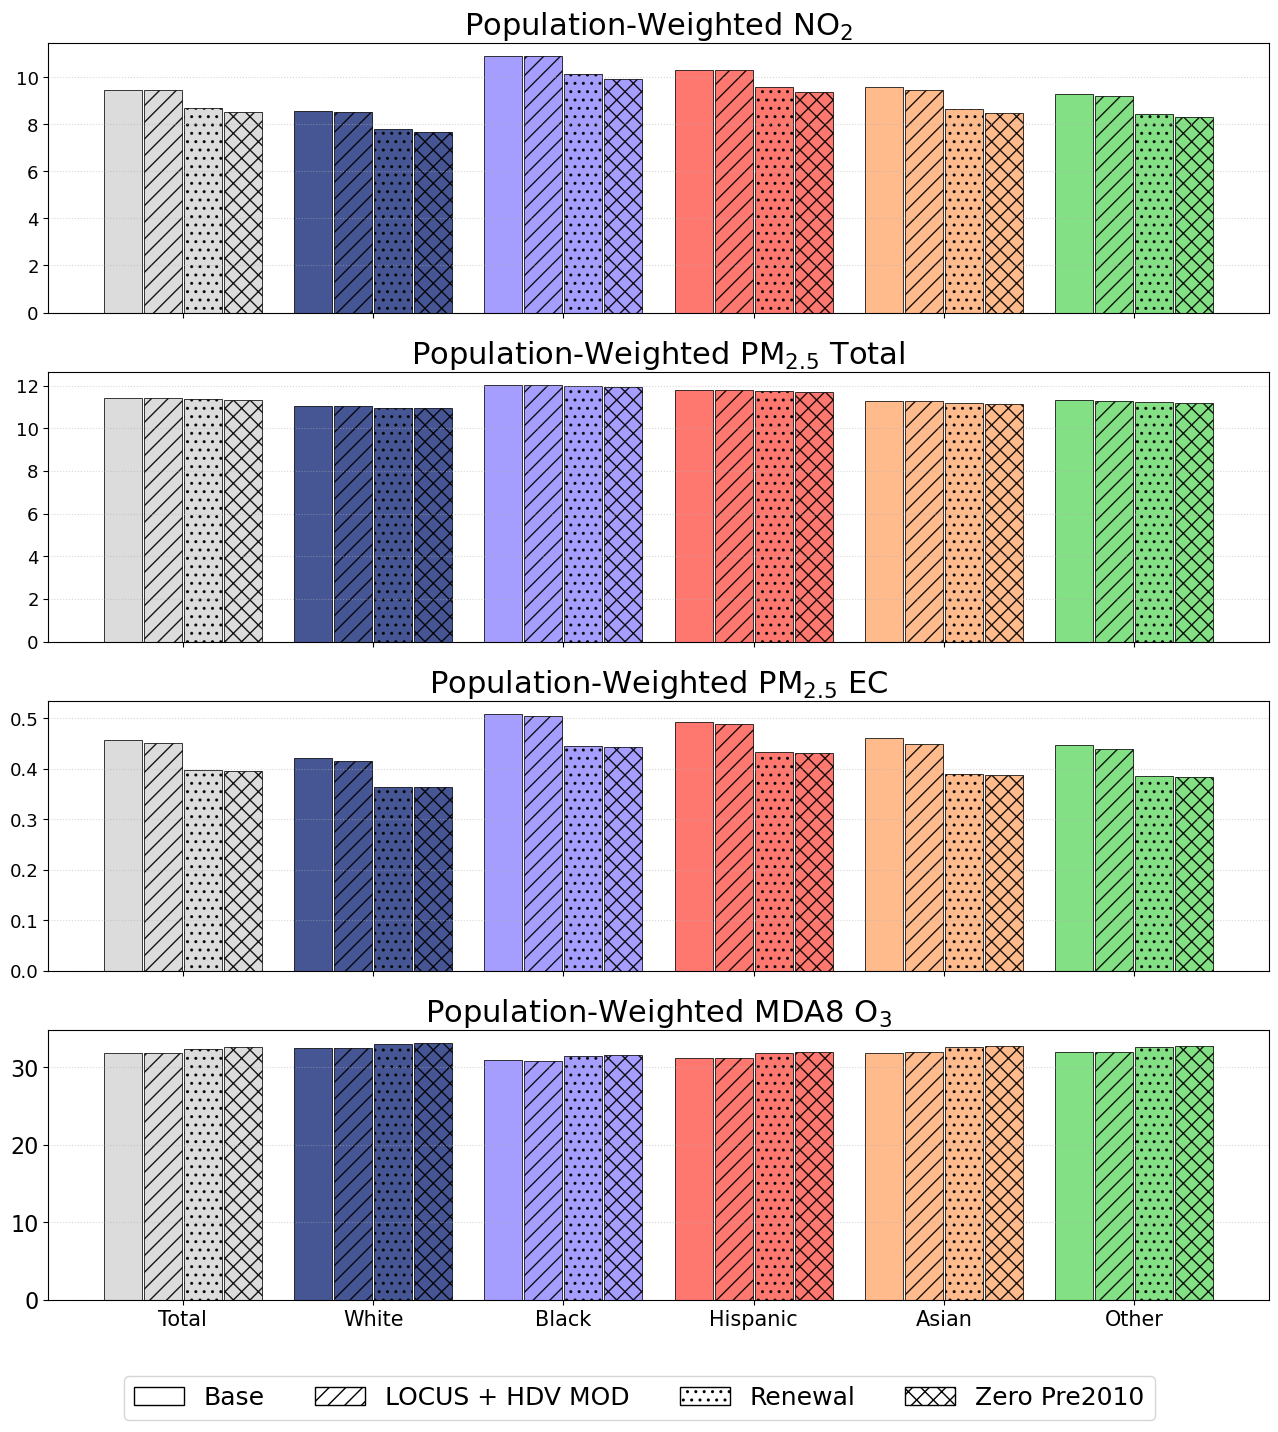

In [228]:
fig, axes = plt.subplots(4, 1, figsize=(13, 15), sharex=True)

x = np.arange(len(subgroups_for_plot))
cluster_w = 0.84
bar_w = cluster_w / len(scenario_keys)
offsets = (np.arange(len(scenario_keys)) - (len(scenario_keys) - 1) / 2) * bar_w

# --- NO2 ---
ax = axes[0]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(
            x[i] + offsets[s],
            no2_vals[s, i],
            width=bar_w * 0.95,
            color=colors_for_plot[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )
ax.set_title("Population-Weighted NO$_2$", fontsize=22)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis='y', labelsize=13)

# --- PM25 total ---
ax = axes[1]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(
            x[i] + offsets[s],
            pm25tot_vals[s, i],
            width=bar_w * 0.95,
            color=colors_for_plot[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )
ax.set_title("Population-Weighted PM$_{2.5}$ Total", fontsize=22)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis='y', labelsize=13)

# --- PM25 EC ---
ax = axes[2]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(
            x[i] + offsets[s],
            pm25ec_vals[s, i],
            width=bar_w * 0.95,
            color=colors_for_plot[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )
ax.set_title("Population-Weighted PM$_{2.5}$ EC", fontsize=22)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis='y', labelsize=13)

# --- O3 ---
ax = axes[3]
for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups_for_plot):
        ax.bar(
            x[i] + offsets[s],
            o3_vals[s, i],
            width=bar_w * 0.95,
            color=colors_for_plot[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9
        )
ax.set_title("Population-Weighted MDA8 O$_3$", fontsize=22)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.tick_params(axis='y', labelsize=16)

axes[3].set_xticks(x)
axes[3].set_xticklabels(subgroups_for_plot, fontsize=15)

# ------------------------------------------------------------
# legends
# ------------------------------------------------------------
race_patches = [
    mpatches.Patch(facecolor=colors_for_plot[g], edgecolor="black", label=g)
    for g in subgroups_for_plot
]

scenario_patches = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatches[k],
        label=scenario_labels[i]
    )
    for i, k in enumerate(scenario_keys)
]

# fig.legend(
#     handles=race_patches,
#     fontsize=18,
#     loc="upper center",
#     ncol=6,
#     frameon=True,
#     bbox_to_anchor=(0.5, 1.01)
# )

fig.legend(
    handles=scenario_patches,
    fontsize=18,
    loc="lower center",
    ncol=4,
    frameon=True
)
plt.savefig('Fig18_JanuaryJulyAvg_PWConcentrations.png')
plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

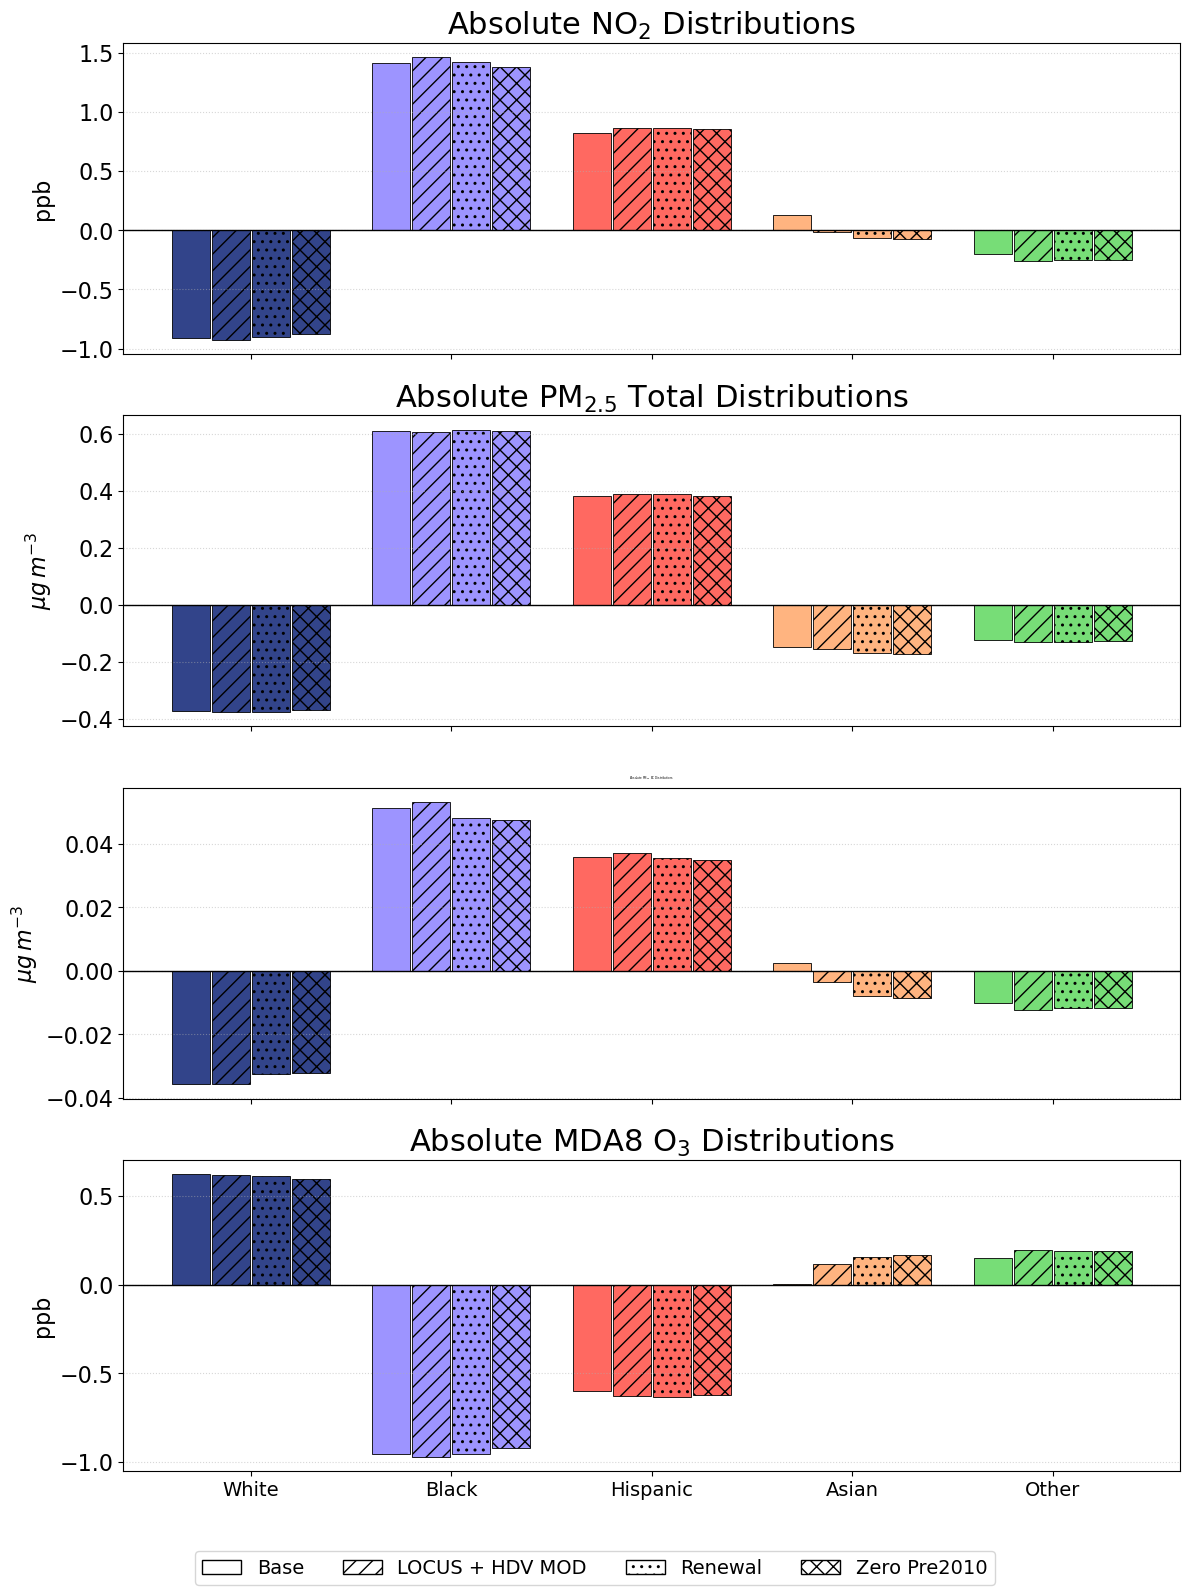

In [227]:
subgroups = ["White", "Black", "Hispanic", "Asian", "Other"]
scenario_keys = ["Base", "Idling", "Renewal", "LegacyRemoval"]
scenario_labels = ["Base", "LOCUS + HDV MOD", "Renewal", "Zero Pre2010"]

colors = {
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77",
}

hatches = {
    "Base": "",
    "Idling": "//",
    "Renewal": "..",
    "LegacyRemoval": "xx"
}

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

x = np.arange(len(subgroups))
cluster_w = 0.8
bar_w = cluster_w / len(scenario_keys)
offsets = (np.arange(len(scenario_keys)) - (len(scenario_keys)-1)/2) * bar_w

# ------------------------------------------------------------
# NO2 absolute disparities
# ------------------------------------------------------------
ax = axes[0]

for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups):
        ax.bar(
            x[i] + offsets[s],
            no2_summary.loc[g, f"{key}_Absolute"],
            width=bar_w * 0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Absolute NO$_2$ Distributions", fontsize=22)
ax.set_ylabel("ppb", fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis="y", linestyle=":", alpha=0.5)

# ------------------------------------------------------------
# PM25_TOT absolute disparities
# ------------------------------------------------------------
ax = axes[1]

for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups):
        ax.bar(
            x[i] + offsets[s],
            pm25_tot_summary.loc[g, f"{key}_Absolute"],
            width=bar_w * 0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Absolute PM$_{2.5}$ Total Distributions", fontsize=22)
ax.set_ylabel(r"$\mu g \, m^{-3}$", fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis="y", linestyle=":", alpha=0.5)

# ------------------------------------------------------------
# PM25_EC absolute disparities
# ------------------------------------------------------------
ax = axes[2]

for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups):
        ax.bar(
            x[i] + offsets[s],
            pm25_ec_summary.loc[g, f"{key}_Absolute"],
            width=bar_w * 0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Absolute PM$_{2.5}$ EC Distributions", fontsize=2)
ax.set_ylabel(r"$\mu g \, m^{-3}$", fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis="y", linestyle=":", alpha=0.5)

# ------------------------------------------------------------
# O3 absolute disparities
# ------------------------------------------------------------
ax = axes[3]

for s, key in enumerate(scenario_keys):
    for i, g in enumerate(subgroups):
        ax.bar(
            x[i] + offsets[s],
            O3_summary.loc[g, f"{key}_Absolute"],
            width=bar_w * 0.95,
            color=colors[g],
            hatch=hatches[key],
            edgecolor="black",
            linewidth=0.6
        )

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Absolute MDA8 O$_3$ Distributions", fontsize=22)
ax.set_ylabel("ppb", fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[3].set_xticks(x)
axes[3].set_xticklabels(subgroups, fontsize=14)

scenario_patches = [
    mpatches.Patch(facecolor="white", edgecolor="black", hatch=hatches[k], label=scenario_labels[i])
    for i, k in enumerate(scenario_keys)
]

fig.legend(
    handles=scenario_patches,
    loc="lower center",
    ncol=4,
    fontsize=14,
    frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('Fig19_JanuaryJulyAvg_ConcentrationsAbsoluteDisparities.png')
plt.show()

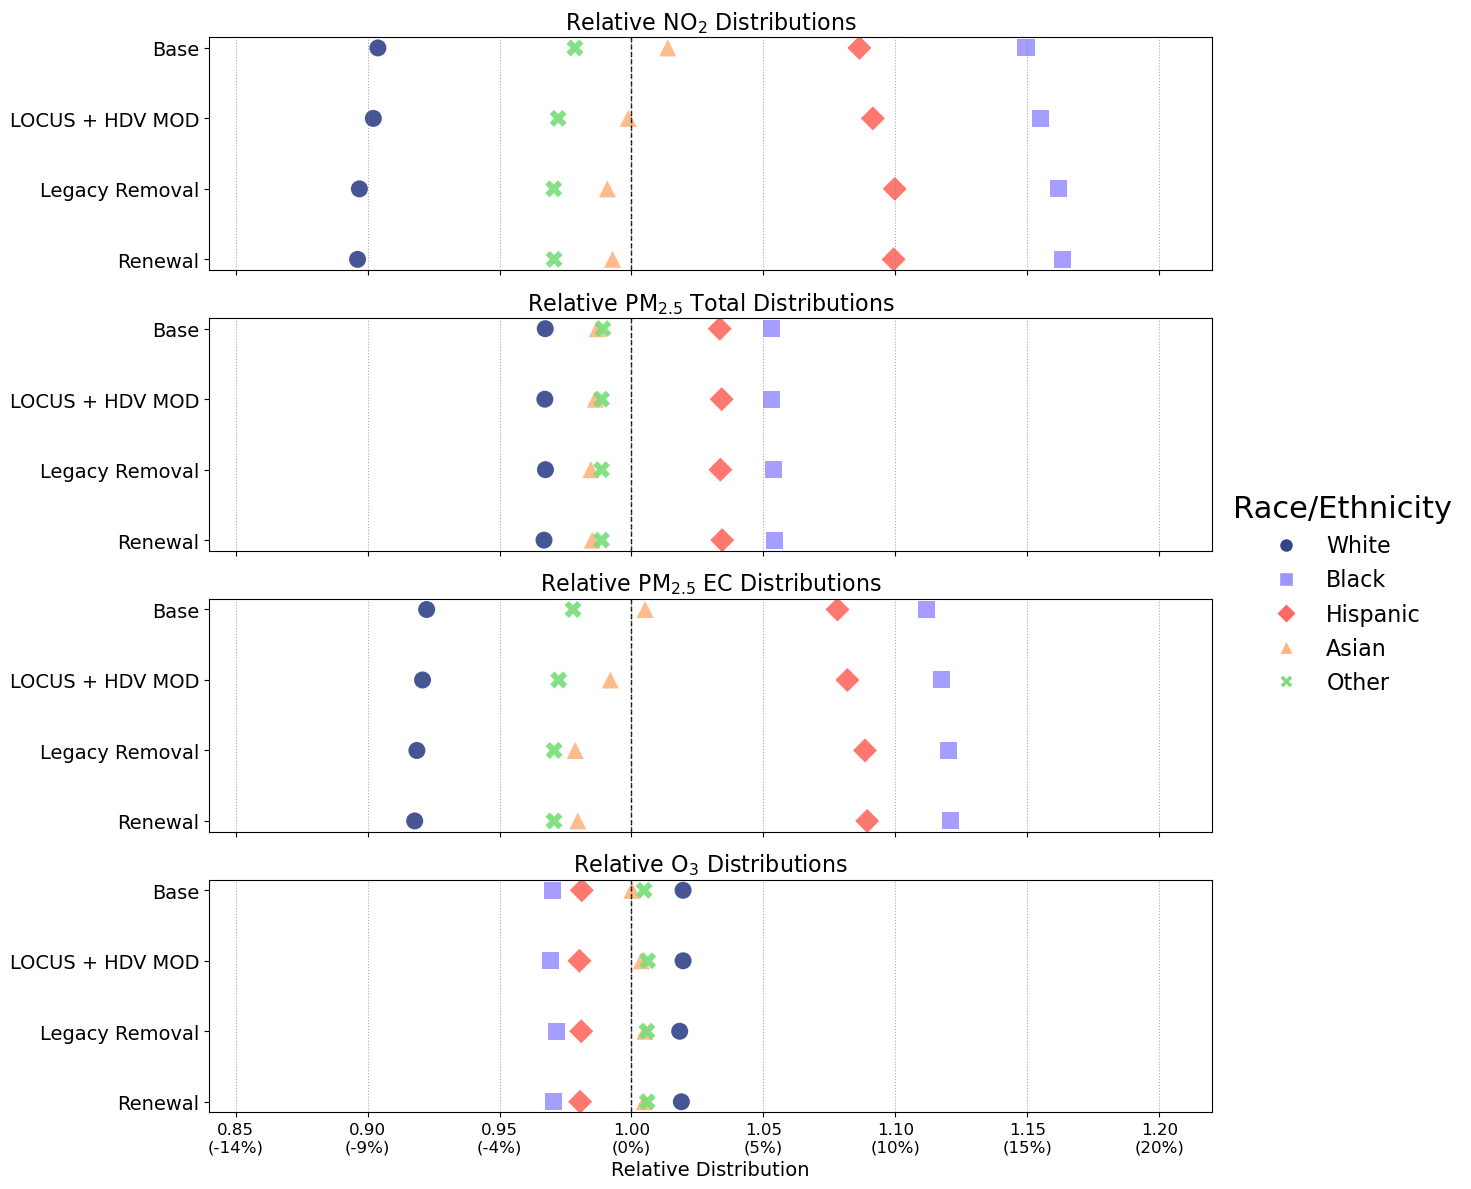

In [217]:
# ============================================================
# RELATIVE DISPARITIES (UPDATED AXIS: 0.90–1.20)
# ============================================================

subgroups = ["White", "Black", "Hispanic", "Asian", "Other"]

markers = {
    "White": "o",
    "Black": "s",
    "Hispanic": "D",
    "Asian": "^",
    "Other": "X",
}

colors = {
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77",
}

xticks = np.arange(0.80, 1.201, 0.05)
xtick_labels = [f"{x:.2f}\n({int((x-1)*100)}%)" for x in xticks]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# ------------------------------------------------------------
# helper function to avoid repetition
# ------------------------------------------------------------
def plot_panel(ax, rows, title):
    ypos = np.arange(len(rows))

    for j, (row_label, tbl, key) in enumerate(rows):
        for g in subgroups:
            x_val = tbl.loc[g, f"{key}_Relative"]

            ax.scatter(
                x_val, j,
                s=150,
                marker=markers[g],
                color=colors[g],
                alpha=0.9,
                edgecolor="none"
            )

    ax.set_yticks(ypos)
    ax.set_yticklabels([r[0] for r in rows], fontsize=14)
    ax.set_title(title, fontsize=16)

    ax.axvline(1.0, color="k", linestyle="--", linewidth=1)

    for xv in xticks:
        if xv != 1.0:
            ax.axvline(xv, color="grey", linestyle=":", linewidth=0.8, alpha=0.7)

# ------------------------------------------------------------
# NO2
# ------------------------------------------------------------
rows_no2 = [
    ("Renewal", no2_summary, "Renewal"),
    ("Legacy Removal", no2_summary, "LegacyRemoval"),
    ("LOCUS + HDV MOD", no2_summary, "Idling"),
    ("Base", no2_summary, "Base"),
]
plot_panel(axes[0], rows_no2, "Relative NO$_2$ Distributions")

# ------------------------------------------------------------
# PM25_TOT
# ------------------------------------------------------------
rows_pm25tot = [
    ("Renewal", pm25_tot_summary, "Renewal"),
    ("Legacy Removal", pm25_tot_summary, "LegacyRemoval"),
    ("LOCUS + HDV MOD", pm25_tot_summary, "Idling"),
    ("Base", pm25_tot_summary, "Base"),
]
plot_panel(axes[1], rows_pm25tot, "Relative PM$_{2.5}$ Total Distributions")

# ------------------------------------------------------------
# PM25_EC
# ------------------------------------------------------------
rows_pm25ec = [
    ("Renewal", pm25_ec_summary, "Renewal"),
    ("Legacy Removal", pm25_ec_summary, "LegacyRemoval"),
    ("LOCUS + HDV MOD", pm25_ec_summary, "Idling"),
    ("Base", pm25_ec_summary, "Base"),
]
plot_panel(axes[2], rows_pm25ec, "Relative PM$_{2.5}$ EC Distributions")

# ------------------------------------------------------------
# O3
# ------------------------------------------------------------
rows_o3 = [
    ("Renewal", O3_summary, "Renewal"),
    ("Legacy Removal", O3_summary, "LegacyRemoval"),
    ("LOCUS + HDV MOD", O3_summary, "Idling"),
    ("Base", O3_summary, "Base"),
]
plot_panel(axes[3], rows_o3, "Relative O$_3$ Distributions")

# ------------------------------------------------------------
# x-axis formatting
# ------------------------------------------------------------
axes[3].set_xticks(xticks)
axes[3].set_xticklabels(xtick_labels, fontsize=12)
axes[3].set_xlim(0.84, 1.22)
axes[3].set_xlabel("Relative Distribution", fontsize=14)

# ------------------------------------------------------------
# legend
# ------------------------------------------------------------
legend_handles = [
    Line2D([0],[0], marker=markers[g], color="w",
           markerfacecolor=colors[g],
           markersize=10,
           label=g)
    for g in subgroups
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.870,0.5),
    frameon=False,
    title="Race/Ethnicity",
    title_fontsize=22,
    fontsize=16
)

plt.tight_layout(rect=[0,0,0.88,1])
plt.savefig('January2023ConcentrationsRelativeDisparities.pdf')
plt.show()

<h1> Chicago Analysis

In [150]:
#chi 7 counties surrounding Chicago/Cook County
chi_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/geo_export_77af1a6a-f8ec-47f4-977c-40956cd94f97.shp')
chi_cty = chi_cty.to_crs('EPSG:4326')

#Clip geopandas files to chi
chi_roads = gpd.clip(primary_roads, chi_cty.to_crs('EPSG:4326'))
chi_base = gpd.clip(base, chi_cty.to_crs('EPSG:4326'))
chi_idling = gpd.clip(idling, chi_cty.to_crs('EPSG:4326'))
chi_renewal = gpd.clip(renewal, chi_cty.to_crs('EPSG:4326'))
chi_zeropre2010s = gpd.clip(zeropre2010s, chi_cty.to_crs('EPSG:4326'))

chi_base_o3 = gpd.clip(base_o3, chi_cty.to_crs('EPSG:4326'))
chi_idling_o3 = gpd.clip(idling_o3, chi_cty.to_crs('EPSG:4326'))
chi_renewal_o3 = gpd.clip(renewal_o3, chi_cty.to_crs('EPSG:4326'))
chi_zeropre2010s_o3 = gpd.clip(zeropre2010s_o3, chi_cty.to_crs('EPSG:4326'))
domain_demo_chi   = gpd.clip(demo_joined,  chi_cty.to_crs('EPSG:4326'))


In [195]:
pollutants_chi = ["NO2", "PM25_EC", "PM25_TOT"]

base_pollutants_chi = chi_base[["GEOID"] + pollutants_chi].copy()
base_pollutants_chi = base_pollutants_chi.rename(
    columns={col: f"base_{col}" for col in pollutants_chi}
)

idling_pollutants_chi = chi_idling[["GEOID"] + pollutants_chi].copy()
idling_pollutants_chi = idling_pollutants_chi.rename(
    columns={col: f"idling_{col}" for col in pollutants_chi}
)

renewal_pollutants_chi = chi_renewal[["GEOID"] + pollutants_chi].copy()
renewal_pollutants_chi = renewal_pollutants_chi.rename(
    columns={col: f"renewal_{col}" for col in pollutants_chi}
)

zeropre2010s_pollutants_chi = chi_zeropre2010s[["GEOID"] + pollutants_chi].copy()
zeropre2010s_pollutants_chi = zeropre2010s_pollutants_chi.rename(
    columns={col: f"zeropre2010s_{col}" for col in pollutants_chi}
)


base_o3_col_chi = chi_base_o3[["GEOID", "O3"]].copy()
base_o3_col_chi = base_o3_col_chi.rename(columns={"O3": "base_O3"})

idling_o3_col_chi = chi_idling_o3[["GEOID", "O3"]].copy()
idling_o3_col_chi = idling_o3_col_chi.rename(columns={"O3": "idling_O3"})

renewal_o3_col_chi = chi_renewal_o3[["GEOID", "O3"]].copy()
renewal_o3_col_chi = renewal_o3_col_chi.rename(columns={"O3": "renewal_O3"})

zeropre2010s_o3_col_chi = chi_zeropre2010s_o3[["GEOID", "O3"]].copy()
zeropre2010s_o3_col_chi = zeropre2010s_o3_col_chi.rename(
    columns={"O3": "zeropre2010s_O3"}
)


aq_scenarios_chi = (
    base_pollutants_chi
    .merge(idling_pollutants_chi, on="GEOID", how="inner")
    .merge(renewal_pollutants_chi, on="GEOID", how="inner")
    .merge(zeropre2010s_pollutants_chi, on="GEOID", how="inner")
    .merge(base_o3_col_chi, on="GEOID", how="inner")
    .merge(idling_o3_col_chi, on="GEOID", how="inner")
    .merge(renewal_o3_col_chi, on="GEOID", how="inner")
    .merge(zeropre2010s_o3_col_chi, on="GEOID", how="inner")
)

full_merged_chi = (
    domain_demo_chi
    .merge(aq_scenarios_chi, on="GEOID", how="inner")
    .merge(bmr_wide_df, on="GEOID", how="inner")
)


In [196]:

age_mapping = {
    "0-0": ["Under 5 years"],
    "1-4": ["Under 5 years"],
    "5-14": ["5 to 9 years", "10 to 14 years"],
    "15-24": ["15 to 17 years", "18 and 19 years", "20 years", "21 years", "22 to 24 years"],
    "25-34": ["25 to 29 years", "30 to 34 years"],
    "35-44": ["35 to 39 years", "40 to 44 years"],
    "45-54": ["45 to 49 years", "50 to 54 years"],
    "55-64": ["55 to 59 years", "60 and 61 years", "62 to 64 years"],
    "65-74": ["65 and 66 years", "67 to 69 years", "70 to 74 years"],
    "75-84": ["75 to 79 years", "80 to 84 years"],
    "85-99": ["85 years and over"],
}

for bmr_age_group, pop_age_groups in age_mapping.items():

    age_label = bmr_age_group.replace("-", "_")
    bmr_col = f"BMR_{age_label}"

    full_merged_chi[f"BM_M_{age_label}"] = 0
    full_merged_chi[f"BM_F_{age_label}"] = 0

    for pop_age_group in pop_age_groups:

        male_col = male_population_columns.get(pop_age_group)
        female_col = female_population_columns.get(pop_age_group)

        if male_col:
            full_merged_chi[f"BM_M_{age_label}"] += (
                full_merged_chi[bmr_col] * full_merged_chi[male_col]
            )

        if female_col:
            full_merged_chi[f"BM_F_{age_label}"] += (
                full_merged_chi[bmr_col] * full_merged_chi[female_col]
            )


# NOTE: this excludes 30-34 because the 25-34 BMR bin also includes 25-29.
# If you want true age 30+, you may need to split the 25-34 population.
over30_age_labels = ["35_44", "45_54", "55_64", "65_74", "75_84", "85_99"]

bm_male_cols = [f"BM_M_{age}" for age in over30_age_labels]
bm_female_cols = [f"BM_F_{age}" for age in over30_age_labels]

full_merged_chi["BM_Male_Over30"] = full_merged_chi[bm_male_cols].sum(axis=1)
full_merged_chi["BM_Female_Over30"] = full_merged_chi[bm_female_cols].sum(axis=1)

full_merged_chi["BM_Total_Over30"] = (
    full_merged_chi["BM_Male_Over30"]
    + full_merged_chi["BM_Female_Over30"]
)



In [197]:

pollutant_betas = {
    "NO2": {
        "col": "NO2",
        "beta": 0.00738,
        "lower": 0.00187,
        "upper": 0.01096,
    },
    "PM25_TOT": {
        "col": "PM25_TOT",
        "beta": 0.00591,
        "lower": 0.00199,
        "upper": 0.00784,
    },
    "PM25_EC": {
        "col": "PM25_EC",
        "beta": 0.0198,
        "lower": 0.0,
        "upper": 0.0392,
    },
    "O3_WHO": {
        "col": "O3",
        "beta": 0.00956,
        "lower": 0.00488,
        "upper": 0.01420,
    },
    "O3_Turner2016": {
        "col": "O3",
        "beta": 0.00198,
        "lower": 0.000995,
        "upper": 0.00392,
    },
}

scenarios = ["base", "idling", "renewal", "zeropre2010s"]

for pollutant, info in pollutant_betas.items():

    pollutant_col = info["col"]

    for scenario in scenarios:

        conc_col = f"{scenario}_{pollutant_col}"

        af_col = f"AF_{pollutant}_{scenario}"
        af_lower_col = f"AF_{pollutant}_{scenario}_lower"
        af_upper_col = f"AF_{pollutant}_{scenario}_upper"

        crf_col = f"CRF_{pollutant}_{scenario}"
        crf_lower_col = f"CRF_{pollutant}_{scenario}_lower"
        crf_upper_col = f"CRF_{pollutant}_{scenario}_upper"

        full_merged_chi[af_col] = (
            1 - np.exp(-info["beta"] * full_merged_chi[conc_col])
        )

        full_merged_chi[af_lower_col] = (
            1 - np.exp(-info["lower"] * full_merged_chi[conc_col])
        )

        full_merged_chi[af_upper_col] = (
            1 - np.exp(-info["upper"] * full_merged_chi[conc_col])
        )

        full_merged_chi[crf_col] = (
            full_merged_chi["BM_Total_Over30"] * full_merged_chi[af_col]
        )

        full_merged_chi[crf_lower_col] = (
            full_merged_chi["BM_Total_Over30"] * full_merged_chi[af_lower_col]
        )

        full_merged_chi[crf_upper_col] = (
            full_merged_chi["BM_Total_Over30"] * full_merged_chi[af_upper_col]
        )



C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

In [198]:

for pollutant in pollutant_betas.keys():

    # Idling minus baseline
    full_merged_chi[f"CRF_{pollutant}_idling_minus_base"] = (
        full_merged_chi[f"CRF_{pollutant}_idling"]
        - full_merged_chi[f"CRF_{pollutant}_base"]
    )

    full_merged_chi[f"CRF_{pollutant}_idling_minus_base_lower"] = (
        full_merged_chi[f"CRF_{pollutant}_idling_lower"]
        - full_merged_chi[f"CRF_{pollutant}_base_lower"]
    )

    full_merged_chi[f"CRF_{pollutant}_idling_minus_base_upper"] = (
        full_merged_chi[f"CRF_{pollutant}_idling_upper"]
        - full_merged_chi[f"CRF_{pollutant}_base_upper"]
    )

    # Renewal minus idling
    full_merged_chi[f"CRF_{pollutant}_renewal_minus_idling"] = (
        full_merged_chi[f"CRF_{pollutant}_renewal"]
        - full_merged_chi[f"CRF_{pollutant}_idling"]
    )

    full_merged_chi[f"CRF_{pollutant}_renewal_minus_idling_lower"] = (
        full_merged_chi[f"CRF_{pollutant}_renewal_lower"]
        - full_merged_chi[f"CRF_{pollutant}_idling_lower"]
    )

    full_merged_chi[f"CRF_{pollutant}_renewal_minus_idling_upper"] = (
        full_merged_chi[f"CRF_{pollutant}_renewal_upper"]
        - full_merged_chi[f"CRF_{pollutant}_idling_upper"]
    )

    # Zero pre-2010 trucks minus idling
    full_merged_chi[f"CRF_{pollutant}_zeropre2010s_minus_idling"] = (
        full_merged_chi[f"CRF_{pollutant}_zeropre2010s"]
        - full_merged_chi[f"CRF_{pollutant}_idling"]
    )

    full_merged_chi[f"CRF_{pollutant}_zeropre2010s_minus_idling_lower"] = (
        full_merged_chi[f"CRF_{pollutant}_zeropre2010s_lower"]
        - full_merged_chi[f"CRF_{pollutant}_idling_lower"]
    )

    full_merged_chi[f"CRF_{pollutant}_zeropre2010s_minus_idling_upper"] = (
        full_merged_chi[f"CRF_{pollutant}_zeropre2010s_upper"]
        - full_merged_chi[f"CRF_{pollutant}_idling_upper"]
    )

    # Zero pre-2010 trucks minus renewal
    full_merged_chi[f"CRF_{pollutant}_zeropre2010s_minus_renewal"] = (
        full_merged_chi[f"CRF_{pollutant}_zeropre2010s"]
        - full_merged_chi[f"CRF_{pollutant}_renewal"]
    )

    full_merged_chi[f"CRF_{pollutant}_zeropre2010s_minus_renewal_lower"] = (
        full_merged_chi[f"CRF_{pollutant}_zeropre2010s_lower"]
        - full_merged_chi[f"CRF_{pollutant}_renewal_lower"]
    )

    full_merged_chi[f"CRF_{pollutant}_zeropre2010s_minus_renewal_upper"] = (
        full_merged_chi[f"CRF_{pollutant}_zeropre2010s_upper"]
        - full_merged_chi[f"CRF_{pollutant}_renewal_upper"]
    )


C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\Users\x12la\anaconda3\lib\site-packages\geopandas\geodataframe.py:1443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

In [199]:
summary_rows_chi = []

for pollutant in pollutant_betas.keys():

    for scenario in scenarios:
        summary_rows_chi.append({
            "Pollutant": pollutant,
            "Metric": scenario,
            "Total": full_merged_chi[f"CRF_{pollutant}_{scenario}"].sum(),
            "Lower": full_merged_chi[f"CRF_{pollutant}_{scenario}_lower"].sum(),
            "Upper": full_merged_chi[f"CRF_{pollutant}_{scenario}_upper"].sum(),
        })

    for metric in [
        "idling_minus_base",
        "renewal_minus_idling",
        "zeropre2010s_minus_idling",
        "zeropre2010s_minus_renewal",
    ]:
        summary_rows_chi.append({
            "Pollutant": pollutant,
            "Metric": metric,
            "Total": full_merged_chi[f"CRF_{pollutant}_{metric}"].sum(),
            "Lower": full_merged_chi[f"CRF_{pollutant}_{metric}_lower"].sum(),
            "Upper": full_merged_chi[f"CRF_{pollutant}_{metric}_upper"].sum(),
        })


mortality_summary_chi = pd.DataFrame(summary_rows_chi)

mortality_summary_chi["Total"] = mortality_summary_chi["Total"].round(2)
mortality_summary_chi["Lower"] = mortality_summary_chi["Lower"].round(2)
mortality_summary_chi["Upper"] = mortality_summary_chi["Upper"].round(2)

mortality_summary_chi["Total_round10"] = (
    mortality_summary_chi["Total"] / 10
).round() * 10

mortality_summary_chi["Lower_round10"] = (
    mortality_summary_chi["Lower"] / 10
).round() * 10

mortality_summary_chi["Upper_round10"] = (
    mortality_summary_chi["Upper"] / 10
).round() * 10

mortality_summary_chi["Total_round10"] = mortality_summary_chi["Total_round10"].astype(int)
mortality_summary_chi["Lower_round10"] = mortality_summary_chi["Lower_round10"].astype(int)
mortality_summary_chi["Upper_round10"] = mortality_summary_chi["Upper_round10"].astype(int)

mortality_summary_chi

,Pollutant,Metric,Total,Lower,Upper,Total_round10,Lower_round10,Upper_round10
0,NO2,base,2262.93,593.72,3286.26,2260,590,3290
1,NO2,idling,2212.37,579.97,3214.55,2210,580,3210
2,NO2,renewal,2075.68,542.96,3020.09,2080,540,3020
3,NO2,zeropre2010s,2034.54,531.85,2961.48,2030,530,2960
4,NO2,idling_minus_base,-50.57,-13.76,-71.72,-50,-10,-70
5,NO2,renewal_minus_idling,-136.68,-37.01,-194.45,-140,-40,-190
6,NO2,zeropre2010s_minus_idling,-177.82,-48.12,-253.06,-180,-50,-250
7,NO2,zeropre2010s_minus_renewal,-41.14,-11.11,-58.61,-40,-10,-60
8,PM25_TOT,base,1826.94,630.30,2394.89,1830,630,2390
9,PM25_TOT,idling,1819.60,627.71,2385.38,1820,630,2390


In [218]:
chi_base["MDA8O3"] = chi_base_o3["O3"].values
chi_idling["MDA8O3"] = chi_idling_o3["O3"].values
chi_renewal["MDA8O3"] = chi_renewal_o3["O3"].values
chi_zeropre2010s["MDA8O3"] = chi_zeropre2010s_o3["O3"].values
# ============================================================
# Merge Chicago concentration tracts with Chicago demographics
# ============================================================
base_joined_chi = domain_demo_chi.merge(chi_base, on="GISJOIN", how="inner")
idling_joined_chi = domain_demo_chi.merge(chi_idling, on="GISJOIN", how="inner")
renewal_joined_chi = domain_demo_chi.merge(chi_renewal, on="GISJOIN", how="inner")
zerolegacy_joined_chi = domain_demo_chi.merge(chi_zeropre2010s, on="GISJOIN", how="inner")

In [219]:

scenario_dfs_chi = {
    "Base": base_joined_chi,
    "Idling": idling_joined_chi,
    "Renewal": renewal_joined_chi,
    "LegacyRemoval": zerolegacy_joined_chi,
}

scenario_labels = {
    "Base": "Base",
    "Idling": "LOCUS + HDV MOD",
    "Renewal": "Renewal",
    "LegacyRemoval": "Zero Pre2010",
}

pop_cols = {
    "Total": "ASOAE001",
    "White": "ASOAE003",
    "Black": "ASOAE004",
    "Hispanic": "ASOAE012",
    "Asian": "ASOAE006",
    "Other": "OTHER_POP",
}

pollutants_for_summary = {
    "NO2": "NO2",
    "PM25_TOT": "PM25_TOT",
    "PM25_EC": "PM25_EC",
    "O3": "MDA8O3",
}
for df in scenario_dfs_chi.values():
    df["OTHER_POP"] = (
        df["ASOAE001"]
        - (
            df["ASOAE003"]
            + df["ASOAE004"]
            + df["ASOAE006"]
            + df["ASOAE012"]
        )
    )

In [220]:
def make_popweighted_summary_chi(pollutant_name, pollutant_col):

    rows = {}

    for subgroup, pop_col in pop_cols.items():

        row = {}

        for scenario_key, df in scenario_dfs_chi.items():

            pop_weighted = (
                (df[pollutant_col] * df[pop_col]).sum()
                / df[pop_col].sum()
            )

            total_pop_weighted = (
                (df[pollutant_col] * df["ASOAE001"]).sum()
                / df["ASOAE001"].sum()
            )

            relative = pop_weighted / total_pop_weighted
            absolute = pop_weighted - total_pop_weighted

            row[f"{scenario_key}_PopWeighted"] = pop_weighted
            row[f"{scenario_key}_Relative"] = relative
            row[f"{scenario_key}_Absolute"] = absolute

        rows[subgroup] = row

    summary = pd.DataFrame.from_dict(rows, orient="index")
    summary = summary.loc[["Total", "White", "Black", "Hispanic", "Asian", "Other"]]

    print(f"\n=== {pollutant_name} Summary, Chicago subset ===")
    print(summary.round(6).to_string())

    return summary


In [221]:
no2_summary_chi = make_popweighted_summary_chi("NO2", "NO2")
pm25_tot_summary_chi = make_popweighted_summary_chi("PM25_TOT", "PM25_TOT")
pm25_ec_summary_chi = make_popweighted_summary_chi("PM25_EC", "PM25_EC")
O3_summary_chi = make_popweighted_summary_chi("MDA8 O3", "MDA8O3")


=== NO2 Summary, Chicago subset ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute  Renewal_PopWeighted  Renewal_Relative  Renewal_Absolute  LegacyRemoval_PopWeighted  LegacyRemoval_Relative  LegacyRemoval_Absolute
Total            12.772299       1.000000       0.000000           12.420731         1.000000         0.000000            11.615870          1.000000          0.000000                  11.373587                1.000000                0.000000
White            12.739346       0.997420      -0.032952           12.179590         0.980586        -0.241140            11.346847          0.976840         -0.269022                  11.104852                0.976372               -0.268735
Black            12.442897       0.974210      -0.329401           12.201943         0.982385        -0.218787            11.454003          0.986065         -0.161866                  11.222254                0.986694               -

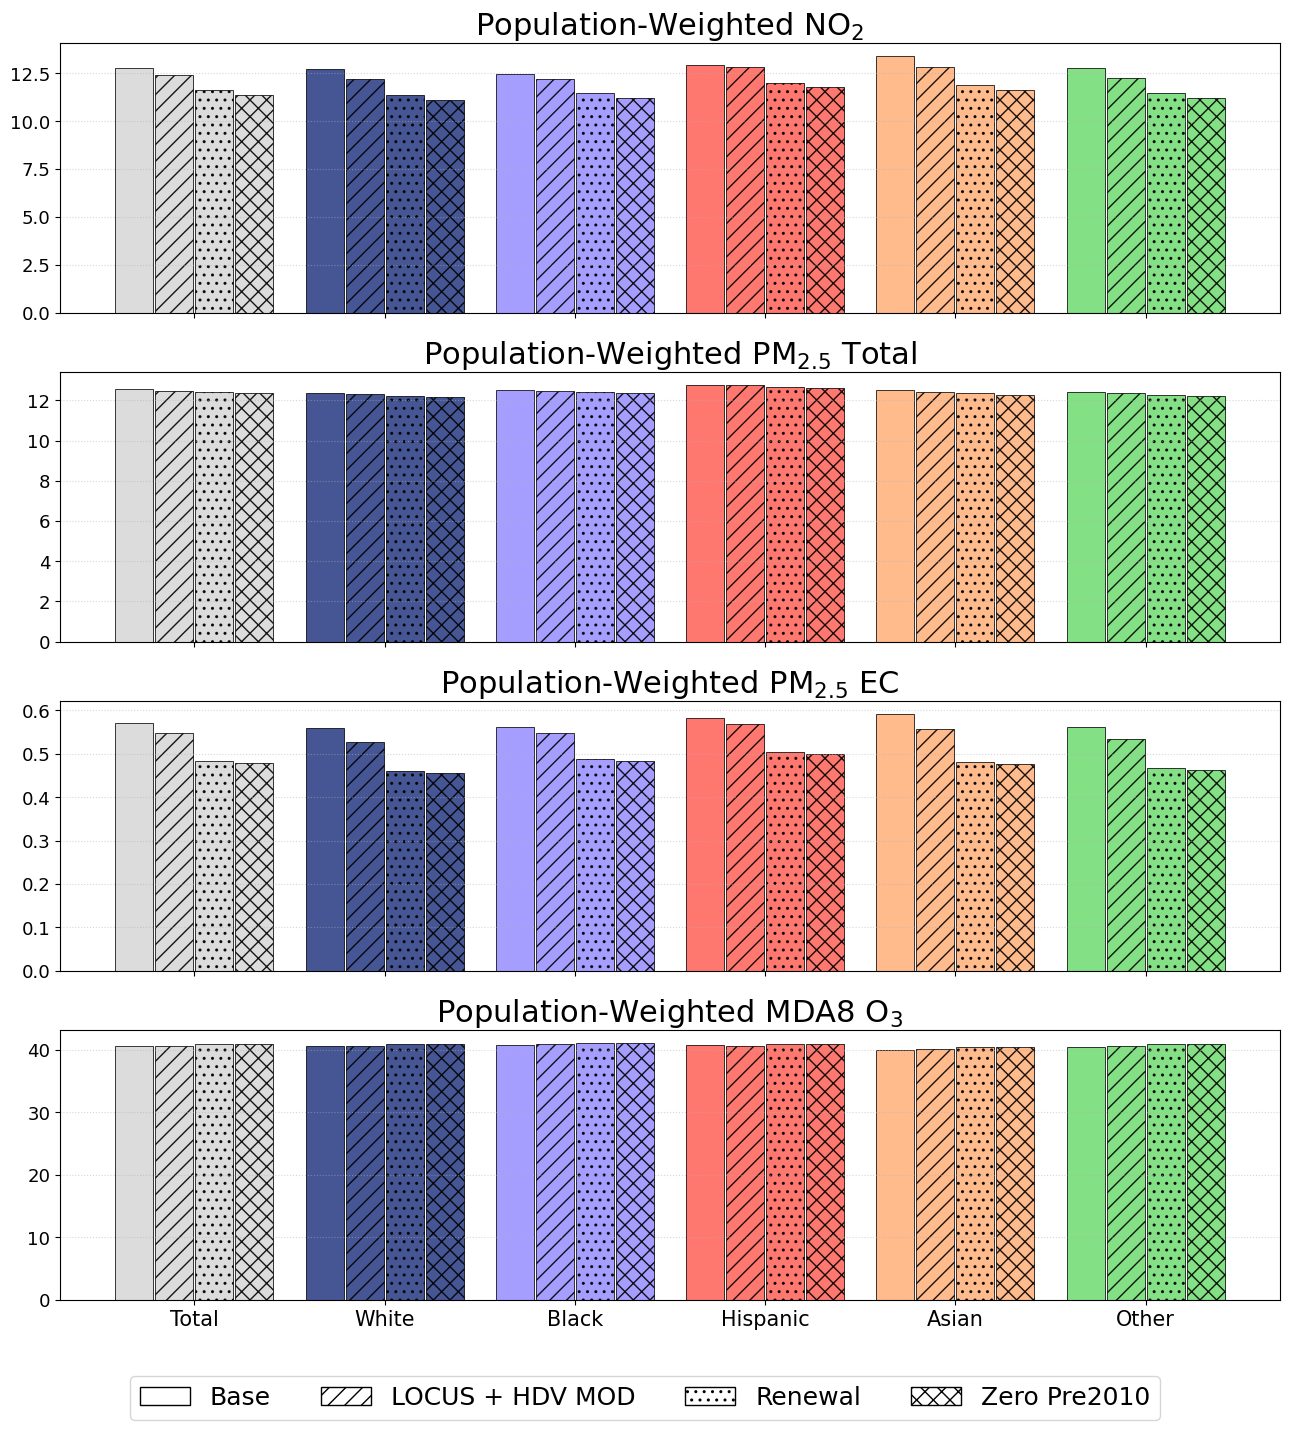

In [225]:
subgroups_for_plot = ["Total", "White", "Black", "Hispanic", "Asian", "Other"]

colors_for_plot = {
    "Total": "#d9d9d9",
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77",
}

hatches = {
    "Base": "",
    "Idling": "//",
    "Renewal": "..",
    "LegacyRemoval": "xx",
}

scenario_keys = ["Base", "Idling", "Renewal", "LegacyRemoval"]
scenario_labels_for_plot = ["Base", "LOCUS + HDV MOD", "Renewal", "Zero Pre2010"]

summary_tables_chi = {
    "NO$_2$": no2_summary_chi,
    "PM$_{2.5}$ Total": pm25_tot_summary_chi,
    "PM$_{2.5}$ EC": pm25_ec_summary_chi,
    "MDA8 O$_3$": O3_summary_chi,
}

fig, axes = plt.subplots(4, 1, figsize=(13, 15), sharex=True)

x = np.arange(len(subgroups_for_plot))
cluster_w = 0.84
bar_w = cluster_w / len(scenario_keys)
offsets = (np.arange(len(scenario_keys)) - (len(scenario_keys) - 1) / 2) * bar_w

for ax, (pollutant_label, summary_df) in zip(axes, summary_tables_chi.items()):

    for s, key in enumerate(scenario_keys):
        for i, subgroup in enumerate(subgroups_for_plot):

            ax.bar(
                x[i] + offsets[s],
                summary_df.loc[subgroup, f"{key}_PopWeighted"],
                width=bar_w * 0.95,
                color=colors_for_plot[subgroup],
                hatch=hatches[key],
                edgecolor="black",
                linewidth=0.6,
                alpha=0.9,
            )

    ax.set_title(f"Population-Weighted {pollutant_label}", fontsize=22)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.tick_params(axis="y", labelsize=13)

axes[3].set_xticks(x)
axes[3].set_xticklabels(subgroups_for_plot, fontsize=15)

scenario_patches = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatches[key],
        label=scenario_labels_for_plot[i],
    )
    for i, key in enumerate(scenario_keys)
]

fig.legend(
    handles=scenario_patches,
    fontsize=18,
    loc="lower center",
    ncol=4,
    frameon=True,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig("ChicagoSubset_PopulationWeightedConcentrations.png")
plt.show()

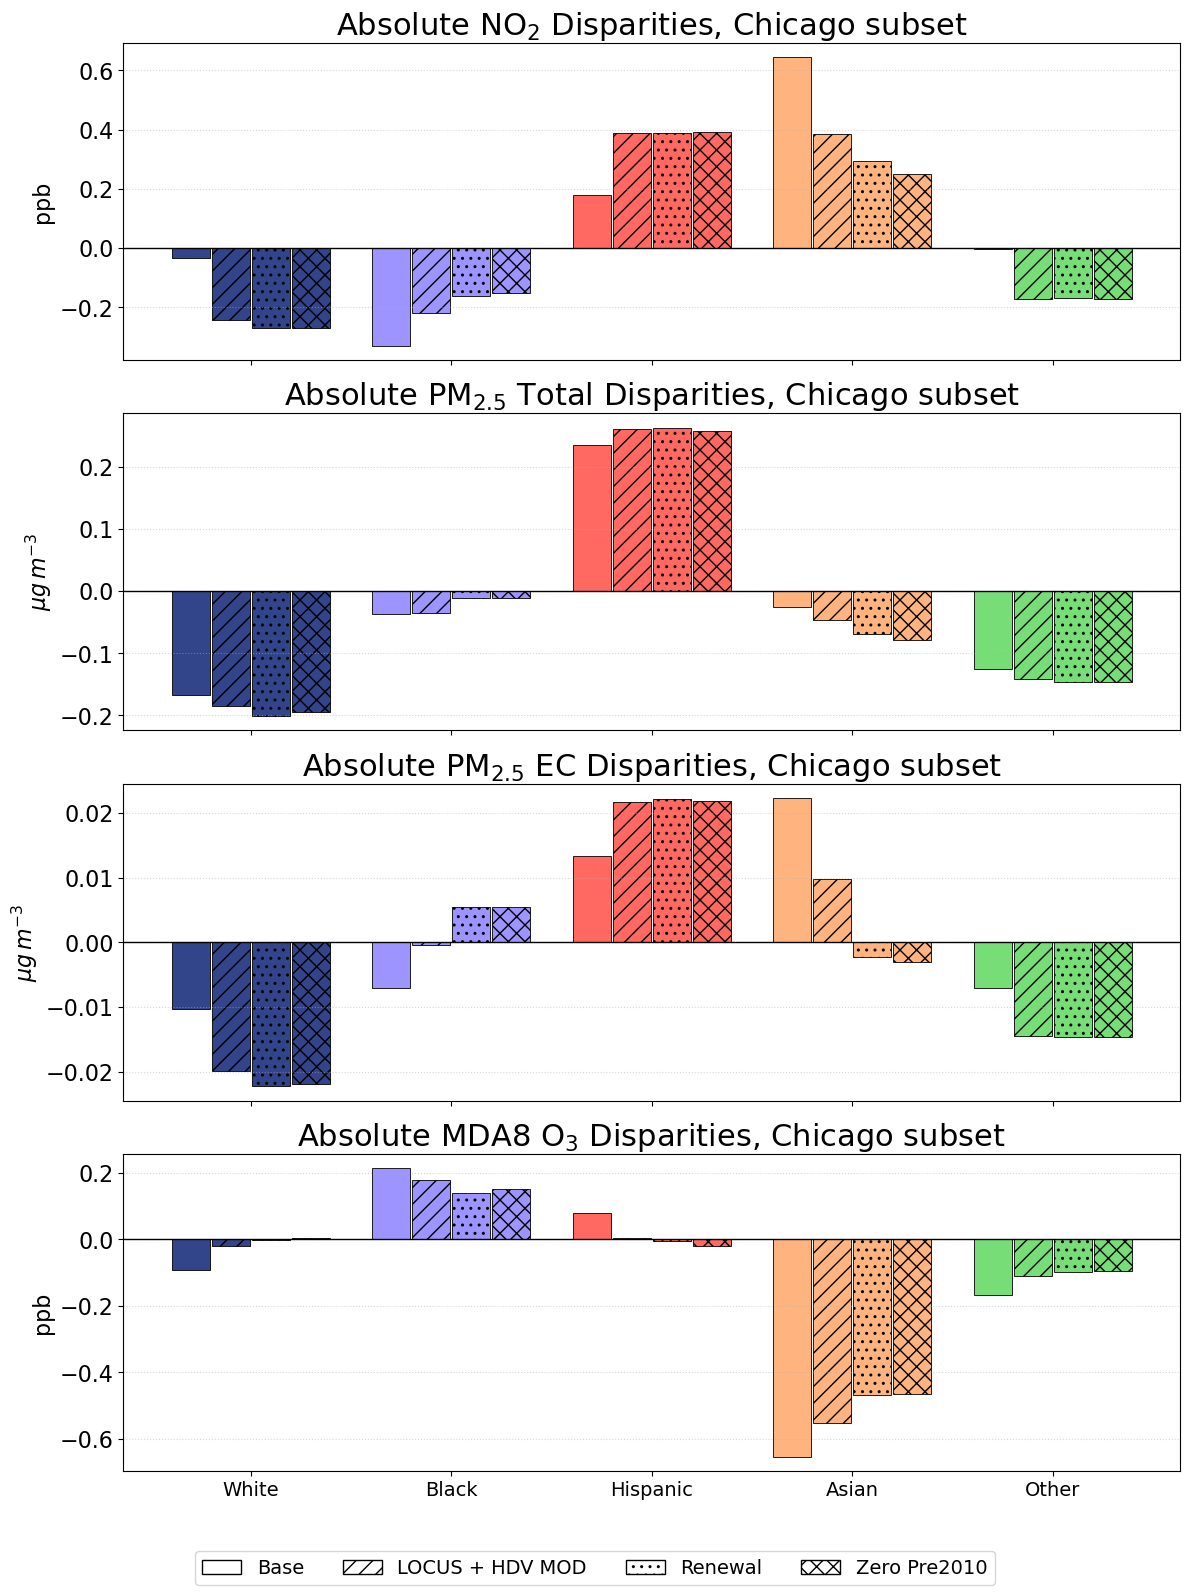

In [224]:
subgroups = ["White", "Black", "Hispanic", "Asian", "Other"]

colors = {
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77",
}

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

x = np.arange(len(subgroups))
cluster_w = 0.8
bar_w = cluster_w / len(scenario_keys)
offsets = (np.arange(len(scenario_keys)) - (len(scenario_keys) - 1) / 2) * bar_w

absolute_plot_info = [
    ("Absolute NO$_2$ Disparities, Chicago subset", no2_summary_chi, "ppb"),
    ("Absolute PM$_{2.5}$ Total Disparities, Chicago subset", pm25_tot_summary_chi, r"$\mu g \, m^{-3}$"),
    ("Absolute PM$_{2.5}$ EC Disparities, Chicago subset", pm25_ec_summary_chi, r"$\mu g \, m^{-3}$"),
    ("Absolute MDA8 O$_3$ Disparities, Chicago subset", O3_summary_chi, "ppb"),
]

for ax, (title, summary_df, ylabel) in zip(axes, absolute_plot_info):

    for s, key in enumerate(scenario_keys):
        for i, subgroup in enumerate(subgroups):

            ax.bar(
                x[i] + offsets[s],
                summary_df.loc[subgroup, f"{key}_Absolute"],
                width=bar_w * 0.95,
                color=colors[subgroup],
                hatch=hatches[key],
                edgecolor="black",
                linewidth=0.6,
            )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title, fontsize=22)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.tick_params(axis="y", labelsize=16)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[3].set_xticks(x)
axes[3].set_xticklabels(subgroups, fontsize=14)

scenario_patches = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatches[key],
        label=scenario_labels_for_plot[i],
    )
    for i, key in enumerate(scenario_keys)
]

fig.legend(
    handles=scenario_patches,
    loc="lower center",
    ncol=4,
    fontsize=14,
    frameon=True,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("ChicagoSubset_ConcentrationsAbsoluteDisparities.png")
plt.show()